# Deepfake Detection Project Walkthrough

In this notebook, we'll walk you through our deepfake detection project, focusing on the steps you'll need to reproduce our final results. We've created a self-contained workflow, which we've distilled from our main development project for ease of use.

We used our main project for research and development, where we experimented extensively with different model architectures, data augmentation strategies, and hyperparameter tuning. In this notebook, we've isolated the final pipeline from that exploratory work to give you a direct method for rerunning our experiments and ensuring their reproducibility.

In this project, we develop two primary models. First, we'll build a classification model that labels image frames as real, synthetic, or tampered. Second, we'll create a segmentation model that identifies the specific manipulated pixels within those tampered frames. In this guide, we'll detail all the run configurations, preprocessing steps, and artifact locations you'll need to replicate our findings.

## Quick-start Guide

First, create and activate a new Conda environment with Python 3.10 or newer:
```bash
conda create -n deepfake-env python=3.10
conda activate deepfake-env
```
(If you prefer `venv`, you can create an environment with `python3 -m venv .venv` and activate it accordingly).

Once your environment is active, install the required packages by running the optional installation cell below. Then, launch Jupyter Notebook or JupyterLab and open this file. Work through the cells from top to bottom, and feel free to stop after the classification section if you do not need the segmentation walkthrough.

In [1]:
# This cell installs the exact libraries and versions needed to reproduce the project results.
# Use this as an alternative to installing packages from your terminal.
%pip install --upgrade pip
%pip install torch==2.8.0 torchvision==0.23.0 datasets scikit-learn matplotlib seaborn pillow tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Verify the runtime

Run the next cell to confirm the Python and PyTorch versions that your environment is using and to check whether CUDA hardware is available. Knowing this up front helps set expectations for training speed and avoids confusion when the GPU path is not accessible.

In [2]:
# The printed summary includes the Python interpreter, the PyTorch build, and the detected GPU name when one is present.
import platform
import torch

print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device    : {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("Running on CPU. Expect training to take a few extra minutes.")

Python version : 3.10.19
PyTorch version: 2.8.0+cu128
CUDA available : True
GPU device    : NVIDIA GeForce RTX 5060 Ti


## Part A — Classification Pipeline
This portion organizes the classification workflow into clearly defined sections.

This first code block is all about setup. We import all the necessary libraries, from standard Python modules for file handling to core machine learning libraries like PyTorch and utility libraries for plotting. We also define a few helper functions to ensure our experiments are reproducible (by setting random seeds) and well-organized (by creating timestamped directories).

In [3]:
# Standard library imports for file paths, JSON handling, and basic utilities.
import json
import math
import random
from collections import defaultdict
from datetime import datetime
from pathlib import Path
from PIL import Image

# Core ML & Data Science libraries for building and training the model.
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch import amp 
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2 as T
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

# Libraries for evaluating results and creating plots.
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix


# Sets random seeds across all libraries to ensure runs are reproducible.
def cls_set_seed(seed: int) -> None:
    """Sets the random seed for all relevant libraries to ensure reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Force cuDNN to use deterministic algorithms for reproducibility.
    torch.backends.cudnn.deterministic = True
    # Disable the cuDNN auto-tuner, as it can select non-deterministic algorithms.
    torch.backends.cudnn.benchmark = False


# Generates a unique timestamp, perfect for naming experiment output folders.
def cls_timestamp() -> str:
    """Returns a standardized UTC timestamp string, useful for unique run IDs."""
    return datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


# Automatically selects the GPU if one is available, otherwise defaults to the CPU.
def cls_device() -> torch.device:
    """Selects and returns the appropriate torch device (GPU if available, else CPU)."""
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


/home/kevin/miniconda3/envs/deepfake-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


To keep our experiments manageable, we resized all our images down. We tested this and found it didn’t result in any real accuracy issues but dramatically sped up our training times, which was a huge win for iterating quickly. For the training process, we started with AdamW because it's a solid, modern optimizer, and then added a cosine scheduler to gradually lower the learning rate, which helped our model converge more effectively. Data augmentation was a real game changer, by randomly transforming the training images, we helped prevent overfitting and made our model better at generalizing. As our list of hyperparameters grew, manually tweaking everything became time consuming, so we used Optuna in our main code to help us tune these knobs and find a strong set of values. Finally, we set a seed to make our results reproducible, for knowing if our changes were actually helping and an output_root to keep all our experiment files neatly organized.

In [4]:
CLASS_CFG = {
    # Dataset window sizes and image resolution (limit pulls from SID_Set + resize for lightweight runs).
    'data': {
        'dataset_name': 'saberzl/SID_Set',      # HF dataset ID supplying Real/Synthetic/Tampered frames.
        'image_size': 224,                      # Final square resolution fed to the CNN.
        'train_samples': 10000,                 # Number of training examples materialised per run.
        'val_samples': 3000,                    # Validation window to monitor generalisation.
    },

    # Canonical class names referenced throughout metrics/plots.
    'class_names': ['Real', 'Synthetic', 'Tampered'],

    # DataLoader orchestration (batching, workers, shuffling) for throughput & determinism.
    'loader': {
        'batch_size': 64,                       # Mini-batch size for all splits.
        'num_workers': 4,                       # Parallel workers per DataLoader.
        'shuffle_train': True,                  # Enable shuffling for training batches.
        'shuffle_eval': False,                  # Keep evaluation order stable for reproducibility.
        'pin_memory': True,                     # Pin host memory to speed GPU transfers.
        'persistent_workers': False,            # Reuse worker processes across epochs when True.
        'prefetch_factor': 2,                   # Number of batches each worker preloads ahead.
    },

    # Model backbone/head knobs pulled in by the Classifier wrapper.
    'model': {
        'backbone': 'resnet50',                      # Backbone identifier (this notebook currently supports ResNet-50).
        'weights': 'DEFAULT',                        # torchvision weights enum to load (None skips pretraining).
        'head': {
            'dropout': 0.3,                         # Dropout probability before the classification layer.
        },
        'freeze': {
            'enabled': True,                         # Freeze early Conv/BN blocks to keep general features.
            'prefixes': ['conv1', 'bn1', 'layer1'],  # Parameter prefixes that remain frozen when enabled.
        },
    },

    # Core training hyperparameters (optimiser + scheduler bundles) that govern optimisation dynamics.
    'training': {
        'learning_rate': 1e-3,                  # Base LR handed to the optimiser.
        'epochs': 30,                           # Number of passes through the training subset.
        'label_smoothing': 0.05,                # Smooths targets to regularise classification.
        'grad_clip_norm': 2.0,                  # Clips gradient norm to stabilise updates.
        'ema_decay': 0.995,                     # Exponential moving average coefficient for weights.
        'use_amp': True,                        # Toggle PyTorch AMP for faster mixed-precision training.
        'optimizer': {
            'name': 'adamw',                    # Optimiser family (adamw, adam, sgd).
            'weight_decay': 1e-4,               # L2 penalty applied to weights.
            'betas': (0.9, 0.999),              # Adam-style momentum coefficients.
        },
        'scheduler': {
            'name': 'cosine',                   # Scheduler type (cosine or onecycle).
            't_max': 30,                        # Cosine period, usually matches number of epochs.
        },
        'loss': {
            'type': 'focal',                   # Emphasises hard examples like subtle tampering.
            'gamma': 2.0,                      # Modulating factor exponent.
            'alpha': None,                     # Optional per-class weights (None keeps equal weighting).
        },
    },

    # Augmentation probabilities and ranges powering optional image-space regularisation.
    'augmentation': {
        'enable': True,                             # Master switch for train-time augmentation.
        'random_resized_crop_scale': (0.6, 1.0),    # Scale bounds for RandomResizedCrop.
        'random_resized_crop_ratio': (0.75, 1.33),  # Aspect-ratio bounds for RandomResizedCrop.
        'horizontal_flip_prob': 0.5,                # Chance of mirroring each training image.
        'perspective_prob': 0.3,                    # Probability of applying RandomPerspective.
        'perspective_distortion': 0.08,             # Distortion strength for perspective warps.
        'color_jitter': {
            'brightness': 0.25,                 # Range for brightness jittering.
            'contrast': 0.25,                   # Range for contrast jittering.
            'saturation': 0.2,                  # Range for saturation jittering.
            'hue': 0.04,                        # Range for hue jittering.
        },
        'blur_prob': 0.3,                       # Probability of applying Gaussian blur.
        'blur_sigma': (0.1, 2.0),               # Sigma range for the blur kernel.
        'random_erasing_prob': 0.25,            # Chance of dropping a random patch.
        'random_erasing_scale': (0.02, 0.2),    # Area range for erased patches.
        'random_erasing_ratio': (0.3, 3.3),     # Aspect-ratio range for erased patches.
    },

    # Global run options (seed for reproducibility, output root for artefacts).
    'seed': 42,
    'output_root': Path('project_outputs_classification'),
}

With our configuration defined, this cell puts it into action. It performs the initial setup for our experiment run: creating the main output directory, setting the global random seed for reproducibility, generating a unique ID for the current run, and creating a dedicated folder to store all its artifacts (like model weights and logs). Finally, it prints the configuration to confirm the settings for this run.

In [5]:
# Step 1 — create the output root and lock the random seed.
CLASS_CFG['output_root'].mkdir(parents=True, exist_ok=True)
cls_set_seed(CLASS_CFG['seed'])

# Step 2 — derive device/run identifiers and ensure the run directory exists.
CLASS_DEVICE = cls_device()                              # Select GPU or CPU.
CLASS_RUN_ID = cls_timestamp()                           # Unique timestamp for this run.
CLASS_RUN_DIR = CLASS_CFG['output_root'] / CLASS_RUN_ID  # Concrete output folder per run.
CLASS_RUN_DIR.mkdir(parents=True, exist_ok=True)

# Step 3 — surface the resolved configuration and target paths.
print('Classification configuration:')

def _json_ready(obj):
    """Convert Paths, tuples, lists, and nested dicts into JSON-friendly primitives."""
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, tuple):
        return [_json_ready(v) for v in obj]
    if isinstance(obj, list):
        return [_json_ready(v) for v in obj]
    if isinstance(obj, dict):
        return {k: _json_ready(v) for k, v in obj.items()}
    return obj

print(json.dumps(_json_ready(CLASS_CFG), indent=2))
print('Device:', CLASS_DEVICE)
print('Output folder:', CLASS_RUN_DIR)


Classification configuration:
{
  "data": {
    "dataset_name": "saberzl/SID_Set",
    "image_size": 224,
    "train_samples": 10000,
    "val_samples": 3000
  },
  "class_names": [
    "Real",
    "Synthetic",
    "Tampered"
  ],
  "loader": {
    "batch_size": 64,
    "num_workers": 4,
    "shuffle_train": true,
    "shuffle_eval": false,
    "pin_memory": true,
    "persistent_workers": false,
    "prefetch_factor": 2
  },
  "model": {
    "backbone": "resnet50",
    "weights": "DEFAULT",
    "head": {
      "dropout": 0.3
    },
    "freeze": {
      "enabled": true,
      "prefixes": [
        "conv1",
        "bn1",
        "layer1"
      ]
    }
  },
  "training": {
    "learning_rate": 0.001,
    "epochs": 30,
    "label_smoothing": 0.05,
    "grad_clip_norm": 2.0,
    "ema_decay": 0.995,
    "use_amp": true,
    "optimizer": {
      "name": "adamw",
      "weight_decay": 0.0001,
      "betas": [
        0.9,
        0.999
      ]
    },
    "scheduler": {
      "name": "cosine

This function, `class_transforms`, acts as a factory for our image transformations. It reads the `augmentation` and `data` sections of our configuration dictionary to build a sequence of preprocessing steps. For training, it includes data augmentation techniques like random cropping, flipping, and color jitter to help the model generalize better. For validation, it applies a simple, deterministic resize to ensure consistent evaluation.

In [6]:
CLASS_NAMES = CLASS_CFG['class_names']  # Label mapping reused by datasets/loaders/metrics.

# Builds torchvision transforms driven entirely by CLASS_CFG so augment knobs live in config.
def class_transforms(cfg: dict, *, is_train: bool) -> T.Compose:
    """
    Builds a torchvision transform pipeline based on the configuration.
    It applies a series of augmentations for training to improve robustness,
    and a simple, deterministic resize for validation to ensure consistent evaluation.

    Args:
        cfg (dict): The main configuration dictionary for the experiment.
        is_train (bool): If True, applies training augmentations. Otherwise, applies validation transforms.

    Returns:
        T.Compose: A composed torchvision transform pipeline.
    """
    data_cfg = cfg['data']
    aug_cfg = cfg['augmentation']
    image_size = data_cfg['image_size']
    augment_enabled = aug_cfg.get('enable', False) and is_train
    ops = []

    # Augmentation Block (for train set only)
    if augment_enabled:
        # Geometric augmentations help the model become invariant to changes in scale, position, and orientation.
        scale_min, scale_max = aug_cfg.get('random_resized_crop_scale', (0.6, 1.0))
        ratio_min, ratio_max = aug_cfg.get('random_resized_crop_ratio', (0.75, 1.33))
        ops.append(T.RandomResizedCrop(image_size, scale=(scale_min, scale_max), ratio=(ratio_min, ratio_max)))

        hflip_prob = aug_cfg.get('horizontal_flip_prob', 0.0)
        if hflip_prob > 0:
            ops.append(T.RandomHorizontalFlip(p=hflip_prob))

        perspective_prob = aug_cfg.get('perspective_prob', 0.0)
        if perspective_prob > 0:
            ops.append(
                T.RandomApply(
                    [T.RandomPerspective(distortion_scale=aug_cfg.get('perspective_distortion', 0.08))],
                    p=perspective_prob,
                )
            )

        # Photometric (color) augmentations help the model become robust to variations in lighting and color.
        cj = aug_cfg.get('color_jitter', {})
        if any(cj.get(key, 0.0) > 0 for key in ('brightness', 'contrast', 'saturation', 'hue')):
            ops.append(
                T.ColorJitter(
                    brightness=cj.get('brightness', 0.0),
                    contrast=cj.get('contrast', 0.0),
                    saturation=cj.get('saturation', 0.0),
                    hue=cj.get('hue', 0.0),
                )
            )

        # Blur augmentation helps the model handle variations in image sharpness.
        blur_prob = aug_cfg.get('blur_prob', 0.0)
        if blur_prob > 0:
            sigma_min, sigma_max = aug_cfg.get('blur_sigma', (0.1, 2.0))
            ops.append(
                T.RandomApply(
                    [T.GaussianBlur(kernel_size=3, sigma=(sigma_min, sigma_max))],
                    p=blur_prob,
                )
            )
    else:
        # For validation/testing, we only apply a deterministic resize to ensure consistency.
        ops.append(T.Resize((image_size, image_size), antialias=True))

    # Mandatory image preprocessing
    # These steps are always applied to prepare the image for the model.
    ops.extend([
        # Convert the PIL Image to a PyTorch tensor.
        T.ToImage(),
        # Convert tensor to float32 and scale pixel values from [0, 255] to [0.0, 1.0].
        T.ToDtype(torch.float32, scale=True),
        # Normalize the tensor using ImageNet's mean and standard deviation. This is done because the pre-trained ResNet backbone expects this input distribution.
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Random Erasing is a regularization technique that randomly occludes parts of the image,
    # forcing the model to learn more robust features. It's often applied after normalization.
    if augment_enabled and aug_cfg.get('random_erasing_prob', 0.0) > 0:
        scale_min, scale_max = aug_cfg.get('random_erasing_scale', (0.02, 0.2))
        ratio_min, ratio_max = aug_cfg.get('random_erasing_ratio', (0.3, 3.3))
        ops.append(
            T.RandomErasing(
                p=aug_cfg['random_erasing_prob'],
                scale=(scale_min, scale_max),
                ratio=(ratio_min, ratio_max),
            )
        )

    # Chain all the selected operations together into a single transform pipeline.
    return T.Compose(ops)

The `ClassificationDataset` class is a wrapper that connects our SID set dataset to PyTorch. Its main job is to take a single data record (an image and its label), apply the appropriate set of transformations (either for training or validation), and return them as tensors ready for the model.

In [7]:
# Dataset Wrapper
# Converts Hugging Face dataset rows into tensors + labels that honour the configured transform.
class ClassificationDataset(Dataset):
    def __init__(self, hf_dataset, cfg: dict, *, is_train: bool):
        self.dataset = hf_dataset
        self.transform = class_transforms(cfg, is_train=is_train)

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        record = self.dataset[idx]
        image = record['image'].convert('RGB')  # HF stores PIL images; convert before transforms.
        tensor = self.transform(image)
        label = torch.tensor(int(record['label']), dtype=torch.long)
        return {'image': tensor, 'label': label}


The `build_class_loaders` function orchestrates the entire data loading pipeline. It fetches the specified number of samples from the Hugging Face dataset, wraps them using our `ClassificationDataset` class, and then creates `DataLoader` objects. These loaders handle batching, shuffling, and parallel data loading to efficiently feed data to the GPU during training.

**Note:** The first time this cell is run, the Hugging Face `datasets` library will automatically download and cache the `'saberzl/SID_Set'` dataset, which may take a few minutes depending on your connection speed.

In [8]:
# DataLoader Factory 
# Pulls bounded splits from SID_Set, applies ClassificationDataset, then instantiates configured DataLoaders.
def build_class_loaders(cfg: dict) -> tuple[DataLoader, DataLoader]:
    data_cfg = cfg['data']
    loader_cfg = cfg['loader']
    dataset_name = data_cfg['dataset_name']

    # The Hugging Face datasets library automatically handles the download and caching
    # of the dataset the first time these lines are executed.
    hf_train = load_dataset(dataset_name, split=f"train[:{data_cfg['train_samples']}]")
    hf_val = load_dataset(dataset_name, split=f"validation[:{data_cfg['val_samples']}]")

    train_ds = ClassificationDataset(hf_train, cfg, is_train=True)
    val_ds = ClassificationDataset(hf_val, cfg, is_train=False)

    pin_memory = loader_cfg.get('pin_memory', True)
    persistent_workers = loader_cfg.get('persistent_workers', False) and loader_cfg['num_workers'] > 0
    loader_kwargs = {
        'batch_size': loader_cfg['batch_size'],
        'num_workers': loader_cfg['num_workers'],
        'pin_memory': pin_memory,
    }
    if persistent_workers:
        loader_kwargs['persistent_workers'] = True
    if loader_cfg['num_workers'] > 0 and loader_cfg.get('prefetch_factor') is not None:
        loader_kwargs['prefetch_factor'] = loader_cfg['prefetch_factor']

    train_loader = DataLoader(
        train_ds,
        shuffle=loader_cfg.get('shuffle_train', True),
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_ds,
        shuffle=loader_cfg.get('shuffle_eval', False),
        **loader_kwargs,
    )

    return train_loader, val_loader

train_loader_c, val_loader_c = build_class_loaders(CLASS_CFG)
print('Classification dataloaders -> train:', len(train_loader_c), 'val:', len(val_loader_c))

Classification dataloaders -> train: 157 val: 47


Before diving into training, it's always a good idea to visually inspect the data our model will see. This cell fetches a few original images from the training set and displays them alongside their augmented counterparts. This direct comparison allows us to quickly sanity-check that our data augmentation pipeline is working as expected and producing a diverse and reasonable, set of transformed images.

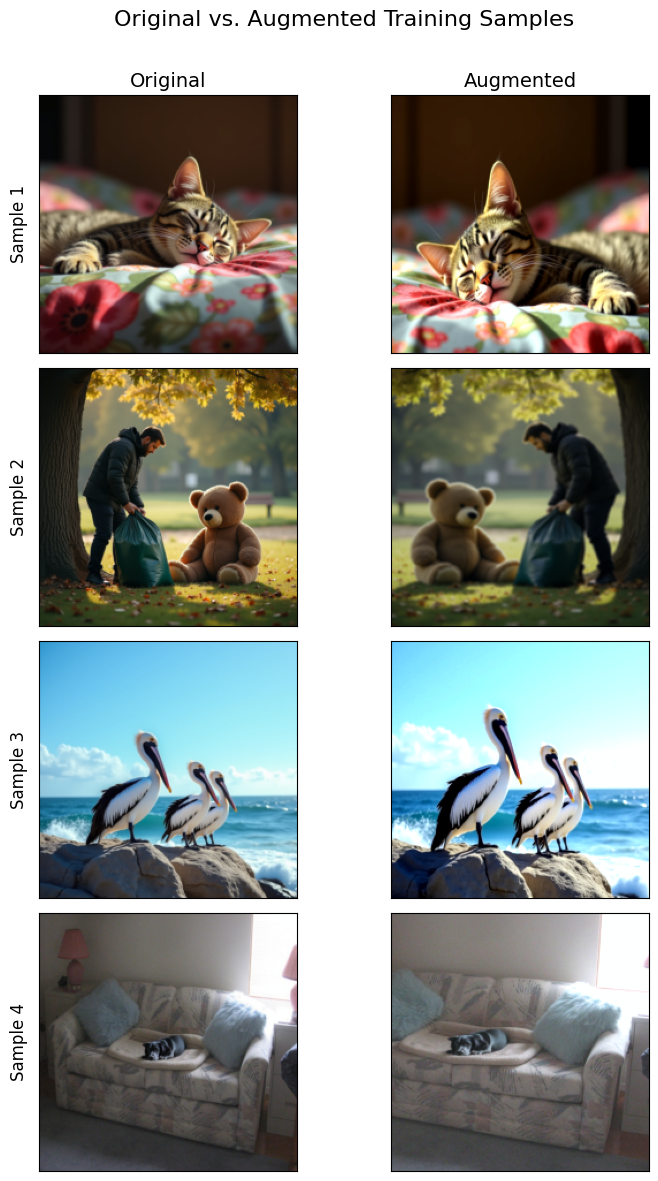

In [9]:
# Visual Inspection Section, comparing original and augmented images

# We'll create a helper function to "denormalize" the image tensors for correct display.
# Our data loader normalizes images with ImageNet stats, so we reverse that process here.
def denormalize(tensor):
    """Reverses the normalization on a tensor for display."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # The tensor is (C, H, W), but matplotlib expects (H, W, C). We also move it to CPU and numpy.
    img_np = tensor.cpu().numpy().transpose((1, 2, 0))
    # Apply the denormalization formula: img = (img * std) + mean
    denormalized_img = std * img_np + mean
    # Clip values to the valid [0, 1] range for image display.
    return np.clip(denormalized_img, 0, 1)

# Define our two transform pipelines: one for augmentation, one for the original view.
aug_transform = class_transforms(CLASS_CFG, is_train=True)
orig_transform = class_transforms(CLASS_CFG, is_train=False)

# Get a few raw samples from the underlying Hugging Face dataset.
num_pairs_to_show = 4
# Access the raw HF dataset from the PyTorch Dataset wrapper.
raw_dataset = train_loader_c.dataset.dataset 

# We'll create a grid of subplots using matplotlib for better control and labeling.
# The grid will have 'num_pairs_to_show' rows and 2 columns (Original vs. Augmented).
fig, axes = plt.subplots(num_pairs_to_show, 2, figsize=(8, 12))
fig.suptitle('Original vs. Augmented Training Samples', fontsize=16)

# Set the titles for our two columns.
axes[0, 0].set_title('Original', fontsize=14)
axes[0, 1].set_title('Augmented', fontsize=14)

for i in range(num_pairs_to_show):
    # Get the raw PIL image from the dataset.
    pil_image = raw_dataset[i]['image'].convert('RGB')
    
    # Apply both transformations to the same source image.
    original_tensor = orig_transform(pil_image)
    augmented_tensor = aug_transform(pil_image)
    
    # Plot the Original Image (Left Column) 
    ax_orig = axes[i, 0]
    ax_orig.imshow(denormalize(original_tensor))
    # Add a label for each row on the y-axis of the first column.
    ax_orig.set_ylabel(f'Sample {i+1}', fontsize=12, labelpad=8)
    # Turn off the ticks and labels for a cleaner look.
    ax_orig.set_xticks([])
    ax_orig.set_yticks([])

    # Plot the Augmented Image (Right Column)
    ax_aug = axes[i, 1]
    ax_aug.imshow(denormalize(augmented_tensor))
    ax_aug.set_xticks([])
    ax_aug.set_yticks([])

# Adjust layout to prevent titles/labels from overlapping.
# The `rect` parameter makes space for the suptitle.
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Here we define our `Classifier` model. It uses a pre-trained ResNet-50 backbone, which has learned feature representations from the large ImageNet dataset. We replace the final fully-connected layer with a new one tailored to our three classes (Real, Synthetic, Tampered) and add a dropout layer for regularization. We also freeze the initial layers of the backbone to retain the general-purpose features learned on ImageNet while fine-tuning the deeper layers for our specific task.

In [10]:
# Model Architecture
class Classifier(nn.Module):
    """
    A Classifier model using a pre-trained ResNet-50 backbone.
    The model is fine-tuned for the Real/Synthetic/Tampered detection task by
    replacing the head and freezing the initial layers.
    """
    def __init__(self, num_classes: int = 3, model_cfg: dict | None = None):
        super().__init__()
        model_cfg = model_cfg or {}

        # Load the pre-trained ResNet-50 backbone.
        self.backbone = self._load_backbone(model_cfg)

        # Create a new classification head and replace the original one.
        head = self._create_head(self.backbone, num_classes, model_cfg)
        self.backbone.fc = head

        # Freeze the initial layers to retain general-purpose features.
        self._freeze_layers(self.backbone, model_cfg)

    def _load_backbone(self, model_cfg: dict) -> nn.Module:
        """Loads the ResNet-50 backbone with specified pre-trained weights."""
        backbone_name = model_cfg.get('backbone', 'resnet50').lower()
        if backbone_name != 'resnet50':
            raise ValueError(f"Unsupported backbone '{backbone_name}'. This notebook currently expects resnet50.")

        weights_key = model_cfg.get('weights', 'DEFAULT')
        weights = None
        if weights_key:
            try:
                # Dynamically get the weights enum (e.g., ResNet50_Weights.DEFAULT)
                weights = getattr(ResNet50_Weights, str(weights_key).upper())
            except AttributeError as exc:
                raise ValueError(f"Unsupported ResNet-50 weights enum '{weights_key}'.") from exc
        
        print(f"Loading ResNet-50 backbone with '{weights_key}' weights.")
        return resnet50(weights=weights)

    def _create_head(self, backbone: nn.Module, num_classes: int, model_cfg: dict) -> nn.Sequential:
        """Creates a new classification head with dropout and a linear layer."""
        head_cfg = model_cfg.get('head', {})
        dropout_p = head_cfg.get('dropout', 0.35)
        
        # Get the number of input features from the backbone's original fc layer.
        in_features = backbone.fc.in_features
        
        head_layers = []
        if dropout_p and dropout_p > 0:
            head_layers.append(nn.Dropout(p=dropout_p))
        head_layers.append(nn.Linear(in_features, num_classes))
        
        return nn.Sequential(*head_layers)

    def _freeze_layers(self, backbone: nn.Module, model_cfg: dict) -> None:
        """Freezes the parameters of the initial layers of the backbone."""
        freeze_cfg = model_cfg.get('freeze', {})
        if not freeze_cfg.get('enabled', True):
            return

        prefixes = tuple(freeze_cfg.get('prefixes', ['conv1', 'bn1', 'layer1']))
        if not prefixes:
            return
            
        print(f"Freezing layers with prefixes: {prefixes}")
        for name, param in backbone.named_parameters():
            if name.startswith(prefixes):
                param.requires_grad_(False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Performs a forward pass through the backbone."""
        return self.backbone(x)

We use Focal Loss instead of standard Cross-Entropy. This loss function helps the model focus on hard-to-classify examples by down-weighting the loss assigned to well-classified ones. It's particularly useful for imbalanced datasets or when some classes (like subtly tampered frames) are harder to detect than others.

In [11]:
# Custom Loss Function — Focal Loss
class FocalLoss(nn.Module):
    """
    Here, we implement our `FocalLoss` class. We chose this over standard Cross-Entropy
    to help our model focus on hard-to-classify examples (the tampered ones). We've also built in optional label smoothing
    for regularization.

    Args:
        gamma (float): The focusing parameter. We use this to scale the loss, giving more weight to hard examples.
        alpha (list or float, optional): We can use this to assign a specific weight to each class.
        reduction (str): We use this to specify how to aggregate the final loss: 'none', 'mean', or 'sum'.
        label_smoothing (float): The epsilon value for label smoothing. We'll set it to 0.0 to disable it.
    """
    def __init__(self, gamma: float = 2.0, alpha: list | float | None = None, reduction: str = 'mean', label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

        # We'll set up the alpha parameter to balance the importance of different classes if provided.
        if alpha is not None:
            alpha_tensor = torch.as_tensor(alpha, dtype=torch.float32)
            # We use register_buffer to make the tensor part of the module's state without it being a trainable parameter.
            self.register_buffer('alpha', alpha_tensor)
        else:
            self.alpha = None

    def _compute_base_ce_loss(self, log_probs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        We created this helper function to calculate the base cross-entropy loss.
        It returns an unreduced loss tensor (one value per sample in the batch),
        applying label smoothing if we've configured it.
        """
        num_classes = log_probs.size(-1)
        
        # If we enabled label smoothing, we'll create a smoothed target distribution.
        if self.label_smoothing > 0 and num_classes > 1:
            # This means the 'true' class gets probability (1 - smoothing), and all others get (smoothing / (C-1)).
            smooth = self.label_smoothing / (num_classes - 1)
            target_dist = torch.full_like(log_probs, smooth)
            target_dist.scatter_(1, targets.unsqueeze(1), 1 - self.label_smoothing)
            # Then, we calculate the loss against this new smoothed distribution.
            ce_loss = -(target_dist * log_probs).sum(dim=1)
        else:
            # Otherwise, we just use the standard Negative Log Likelihood Loss.
            ce_loss = F.nll_loss(log_probs, targets, reduction='none')
            
        return ce_loss

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        This is where we perform the full forward pass to calculate the focal loss.

        Args:
            logits (torch.Tensor): The raw, unnormalized output from our model (shape: [N, C]).
            targets (torch.Tensor): The ground truth labels (shape: [N]).

        Returns:
            torch.Tensor: The final calculated focal loss.
        """
        # 1. First, we get the model's predictions and their probabilities.
        # We use log_softmax for better numerical stability.
        log_probs = F.log_softmax(logits, dim=-1)
        probs = log_probs.exp()
        
        # 2. Next, we calculate the base Cross-Entropy loss using our helper function.
        ce_loss = self._compute_base_ce_loss(log_probs, targets)

        # 3. Then, we get the model's confidence in the correct class for each sample.
        # This corresponds to the 'p_t' term in the original Focal Loss paper.
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        # We'll add a small epsilon to prevent issues if confidence is exactly 0.
        pt = pt.clamp_min(1e-6)

        # 4. Here's the core of Focal Loss: we calculate the modulating factor: (1 - p_t)^gamma.
        # This factor is what down-weights the loss for well-classified examples.
        modulating_factor = (1 - pt) ** self.gamma
        
        # 5. We then apply this modulating factor to the cross-entropy loss.
        loss = modulating_factor * ce_loss
        
        # 6. Optionally, we can also apply the alpha weighting to balance class importance.
        if self.alpha is not None:
            alpha = self.alpha.to(loss.device)
            # We apply the appropriate weight based on the target class of each sample.
            loss = loss * alpha[targets]
            
        # 7. Finally, we apply the specified reduction ('mean' or 'sum') to get the final loss value.
        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss

These helper functions read our `CLASS_CFG` dictionary to build the loss function, optimiser, and learning rate scheduler. This approach keeps the setup modular and ensures that all hyperparameters are managed from a single configuration object.

In [12]:
def build_loss(train_cfg: dict) -> nn.Module:
    """
    We use this function to create our loss criterion based on the training configuration.
    It allows us to easily switch between different loss functions like Focal Loss or standard Cross-Entropy.
    """
    # First, we get the loss configuration from the main training config.
    loss_cfg = train_cfg.get('loss', {})
    loss_type = loss_cfg.get('type', 'cross_entropy').lower()
    
    # If we specified 'focal' in our config, we'll instantiate our custom FocalLoss class.
    if loss_type == 'focal':
        return FocalLoss(
            gamma=loss_cfg.get('gamma', 2.0),
            alpha=loss_cfg.get('alpha'),
            label_smoothing=train_cfg.get('label_smoothing', 0.0),
        )
    
    # Otherwise, we'll fall back to the standard CrossEntropyLoss provided by PyTorch.
    # Note that we pass the `label_smoothing` value to both loss types for consistency.
    return nn.CrossEntropyLoss(label_smoothing=train_cfg.get('label_smoothing', 0.0))


def build_optimizer(parameters, train_cfg: dict):
    """
    Here, we build the optimizer (e.g., AdamW, SGD) based on our configuration.
    This keeps the hyperparameter settings neatly organized in the config dictionary.
    """
    # We get the optimizer's name from the config, defaulting to 'adamw'.
    name = train_cfg['optimizer'].get('name', 'adamw').lower()
    lr = train_cfg['learning_rate']
    opt_cfg = train_cfg['optimizer']
    weight_decay = opt_cfg.get('weight_decay', 0.0)
    betas = opt_cfg.get('betas', (0.9, 0.999))
    
    # Based on the name, we instantiate the correct optimizer with its specific settings.
    if name == 'adam':
        return optim.Adam(parameters, lr=lr, betas=betas, weight_decay=weight_decay)
    if name == 'sgd':
        return optim.SGD(
            parameters,
            lr=lr,
            momentum=opt_cfg.get('momentum', 0.9),
            weight_decay=weight_decay,
            nesterov=opt_cfg.get('nesterov', False),
        )
    
    # AdamW is a great default choice, so we use it if no other optimizer is specified.
    return optim.AdamW(parameters, lr=lr, betas=betas, weight_decay=weight_decay)


def build_scheduler(optimizer, train_cfg: dict, steps_per_epoch: int):
    """
    This function sets up our learning rate scheduler. It's important because it returns not just
    the scheduler itself, but also a string ('epoch' or 'batch') telling our training
    loop when to call the scheduler's step() method.
    """
    sched_cfg = train_cfg.get('scheduler', {})
    name = sched_cfg.get('name', 'none').lower()
    epochs = train_cfg['epochs']

    # For Cosine Annealing, we set it up with T_max and specify that it should be updated each 'epoch'.
    if name == 'cosine':
        t_max = sched_cfg.get('t_max', epochs)
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max), 'epoch'
    
    # For OneCycleLR, it requires more parameters and needs to be updated after every 'batch'.
    if name == 'onecycle':
        max_lr = sched_cfg.get('max_lr', train_cfg['learning_rate'])
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=max_lr,
            epochs=epochs,
            steps_per_epoch=max(steps_per_epoch, 1),
            pct_start=sched_cfg.get('pct_start', 0.3),
            div_factor=sched_cfg.get('div_factor', 25.0),
            final_div_factor=sched_cfg.get('final_div_factor', 10000.0),
        )
        return scheduler, 'batch'
        
    # If no scheduler is specified, we return None.
    return None, 'epoch'

This cell brings everything together. We instantiate the model, loss, and optimiser using our factory functions. We also set up the `GradScaler` for mixed-precision training (AMP) and an Exponential Moving Average (EMA) model, which often provides better generalisation for the final evaluation.

In [13]:
# Model and Optimiser Instantiation
training_cfg = CLASS_CFG['training']

model_c = Classifier(num_classes=len(CLASS_NAMES), model_cfg=CLASS_CFG['model']).to(CLASS_DEVICE)
criterion_c = build_loss(training_cfg)
optimizer_c = build_optimizer(model_c.parameters(), training_cfg)
scheduler_c, scheduler_step_mode = build_scheduler(optimizer_c, training_cfg, len(train_loader_c))

# Setup for Mixed-Precision Training (AMP)
amp_enabled = training_cfg.get('use_amp', True) and CLASS_DEVICE.type == 'cuda'
scaler_c = amp.GradScaler(enabled=amp_enabled)

# Setup for Exponential Moving Average (EMA)
ema_c = Classifier(num_classes=len(CLASS_NAMES), model_cfg=CLASS_CFG['model']).to(CLASS_DEVICE)
ema_c.load_state_dict(model_c.state_dict())
for param in ema_c.parameters():
    param.requires_grad_(False)

Loading ResNet-50 backbone with 'DEFAULT' weights.
Freezing layers with prefixes: ('conv1', 'bn1', 'layer1')
Loading ResNet-50 backbone with 'DEFAULT' weights.
Freezing layers with prefixes: ('conv1', 'bn1', 'layer1')


This is the core training loop. It iterates over the specified number of epochs, and in each epoch, it performs a full pass over the training data to update the model's weights. It then runs a validation pass to evaluate the model's performance on unseen data. We use `tqdm` to create progress bars for both loops. The loop also handles learning rate scheduling, gradient clipping for stability, and updates the Exponential Moving Average (EMA) of the model weights. The best performing model state based on validation accuracy is saved.

In [14]:
# Helper function to update the EMA model's buffers (like BatchNorm stats)
def update_ema_buffers(ema_model, model):
    """
    Syncs buffers (e.g., running_mean, running_var of BatchNorm layers)
    from the trained model to the EMA model.
    """
    for name, buf in model.named_buffers():
        ema_model.state_dict()[name].copy_(buf)
 
# Retrieve training hyperparameters from the configuration dictionary.
training_cfg = CLASS_CFG['training']
epochs = training_cfg['epochs']
grad_clip_norm = training_cfg['grad_clip_norm']
ema_decay = training_cfg['ema_decay']
amp_enabled = training_cfg.get('use_amp', True) and CLASS_DEVICE.type == 'cuda'

# Initialize containers for tracking metrics and saving the best model state.
history_c = defaultdict(list)
best_state_c = None
best_val_acc = -math.inf

# Main Training Loop 
# Iterate over the specified number of epochs.
for epoch in range(epochs):
    model_c.train()  # Set the main model to training mode (enables dropout, etc.).
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    # Wrap the data loader with tqdm for a progress bar during training.
    train_loop = tqdm(train_loader_c, desc=f"Epoch {epoch + 1}/{epochs} [Train]", leave=False)
    
    # Iterate over batches of training data.
    for batch in train_loop:
        images = batch['image'].to(CLASS_DEVICE)
        labels = batch['label'].to(CLASS_DEVICE)

        # Reset gradients from the previous iteration.
        optimizer_c.zero_grad(set_to_none=True)
        
        # Use Automatic Mixed Precision (AMP) for faster training on compatible GPUs.
        with amp.autocast(device_type=CLASS_DEVICE.type, enabled=amp_enabled):
            logits = model_c(images)  # Forward pass
            loss = criterion_c(logits, labels)  # Calculate loss

        # Scale the loss for AMP and perform the backward pass.
        scaler_c.scale(loss).backward()

        # Apply gradient clipping to prevent exploding gradients.
        if grad_clip_norm > 0:
            scaler_c.unscale_(optimizer_c)  # Unscale gradients before clipping
            torch.nn.utils.clip_grad_norm_(model_c.parameters(), grad_clip_norm)

        # Update model weights.
        scaler_c.step(optimizer_c)
        scaler_c.update()

        # Update the Exponential Moving Average (EMA) model weights for smoother, more stable predictions.
        if ema_decay > 0:
            for ema_param, param in zip(ema_c.parameters(), model_c.parameters()):
                ema_param.data.mul_(ema_decay).add_(param.data, alpha=1 - ema_decay)

        # Step the learning rate scheduler if it's updated per batch (e.g., OneCycleLR).
        if scheduler_c is not None and scheduler_step_mode == 'batch':
            scheduler_c.step()

        # Accumulate training metrics for the epoch.
        train_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += images.size(0)

    # Step the learning rate scheduler if it's updated per epoch (e.g., CosineAnnealingLR).
    if scheduler_c is not None and scheduler_step_mode == 'epoch':
        scheduler_c.step()
        
    # Sync the EMA model's buffers (like BatchNorm stats) with the trained model.
    # This is because the EMA weight update only handles parameters, not these
    # running statistics. Without this, the EMA model's BatchNorm layers would have
    # incorrect stats, causing the validation loss to explode.
    if ema_decay > 0:
        update_ema_buffers(ema_c, model_c)

    # Validation 
    model_c.eval()  # Set the main model to evaluation mode.
    ema_c.eval()    # Set the EMA model to evaluation mode (disables dropout, etc.).
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Disable gradient calculations to save memory and speed up validation.
    with torch.no_grad():
        # Wrap the data loader with tqdm for a progress bar during validation.
        val_loop = tqdm(val_loader_c, desc=f"Epoch {epoch + 1}/{epochs} [Val]", leave=False)
        for batch in val_loop:
            images = batch['image'].to(CLASS_DEVICE)
            labels = batch['label'].to(CLASS_DEVICE)
            
            # Use the EMA model for validation as it often generalizes better.
            logits = ema_c(images)
            loss = criterion_c(logits, labels)
            
            # Accumulate validation metrics.
            val_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += images.size(0)

    # Calculate average loss and accuracy for the epoch.
    train_loss /= max(train_total, 1)
    train_acc = train_correct / max(train_total, 1)
    val_loss /= max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)

    # Store the metrics in the history dictionary.
    history_c['train_loss'].append(train_loss)
    history_c['train_acc'].append(train_acc)
    history_c['val_loss'].append(val_loss)
    history_c['val_acc'].append(val_acc)
    history_c['lr'].append(optimizer_c.param_groups[0]['lr'])

    # Print a summary of the epoch's performance.
    print(f"[Classification] Epoch {epoch + 1:02d}/{epochs} train_loss={train_loss:.3f} train_acc={train_acc:.3f} val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

    # Save the model state if it has the best validation accuracy so far.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_c = {k: v.clone() for k, v in ema_c.state_dict().items()}

# After all epochs, load the best model weights back into the EMA model for final evaluation.
if best_state_c is not None:
    ema_c.load_state_dict(best_state_c)

[Classification] Epoch 01/30 train_loss=0.194 train_acc=0.739 val_loss=0.403 val_acc=0.603


[Classification] Epoch 02/30 train_loss=0.149 train_acc=0.793 val_loss=0.198 val_acc=0.707


[Classification] Epoch 03/30 train_loss=0.132 train_acc=0.812 val_loss=0.176 val_acc=0.792


[Classification] Epoch 04/30 train_loss=0.132 train_acc=0.818 val_loss=0.196 val_acc=0.701


[Classification] Epoch 05/30 train_loss=0.117 train_acc=0.834 val_loss=0.121 val_acc=0.842


...

[Classification] Epoch 26/30 train_loss=0.018 train_acc=0.981 val_loss=0.193 val_acc=0.864


[Classification] Epoch 27/30 train_loss=0.015 train_acc=0.983 val_loss=0.196 val_acc=0.870


[Classification] Epoch 28/30 train_loss=0.015 train_acc=0.983 val_loss=0.204 val_acc=0.862


[Classification] Epoch 29/30 train_loss=0.014 train_acc=0.984 val_loss=0.203 val_acc=0.869


[Classification] Epoch 30/30 train_loss=0.013 train_acc=0.986 val_loss=0.203 val_acc=0.866


With the training loop complete, this section handles the evaluation of our best model **on the validation set** and saves all resulting artifacts. It's important to note that this is an intermediate step to gauge generalization, the final evaluation on the held-out **test set** will be covered in Part C.

Here, we will save the best model weights and the training history to disk. Then, we'll calculate a classification report and a confusion matrix to assess the model's performance on the validation data. Finally, we'll generate several plots: loss and accuracy curves, the learning rate schedule, the confusion matrix, and a visual sample of predictions on validation images.

Saved classification model to project_outputs_classification/20251128T120009Z/best_model.pth
Classification macro F1: 0.8815276835651509


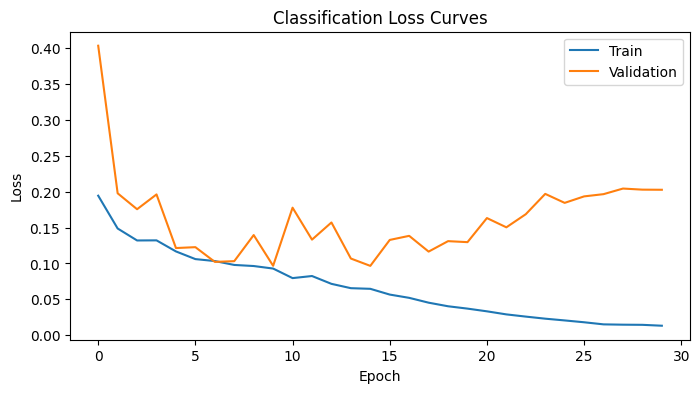

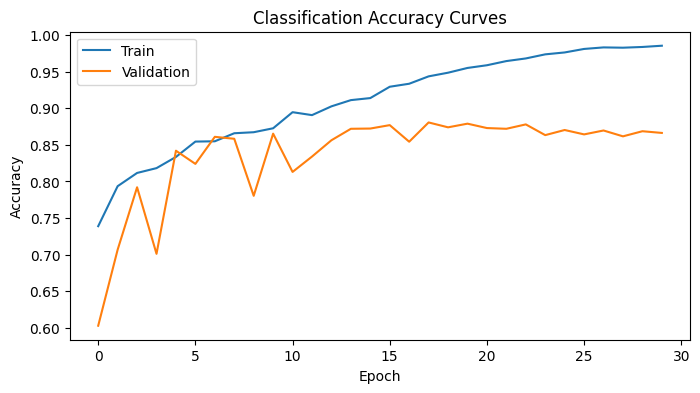

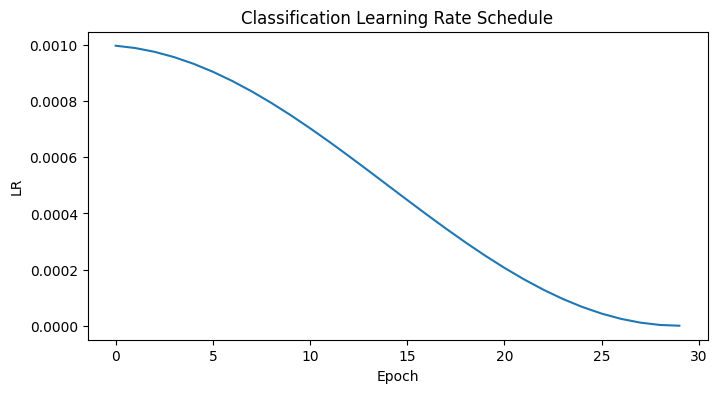

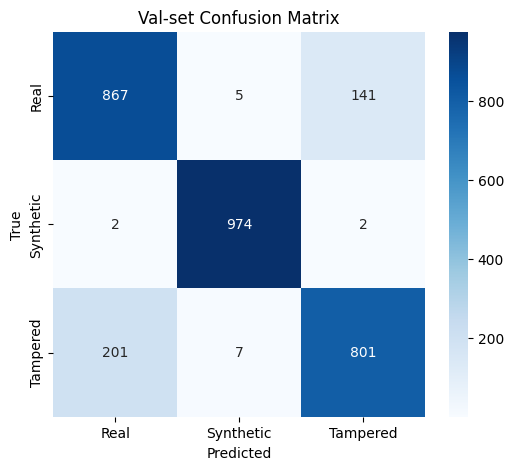

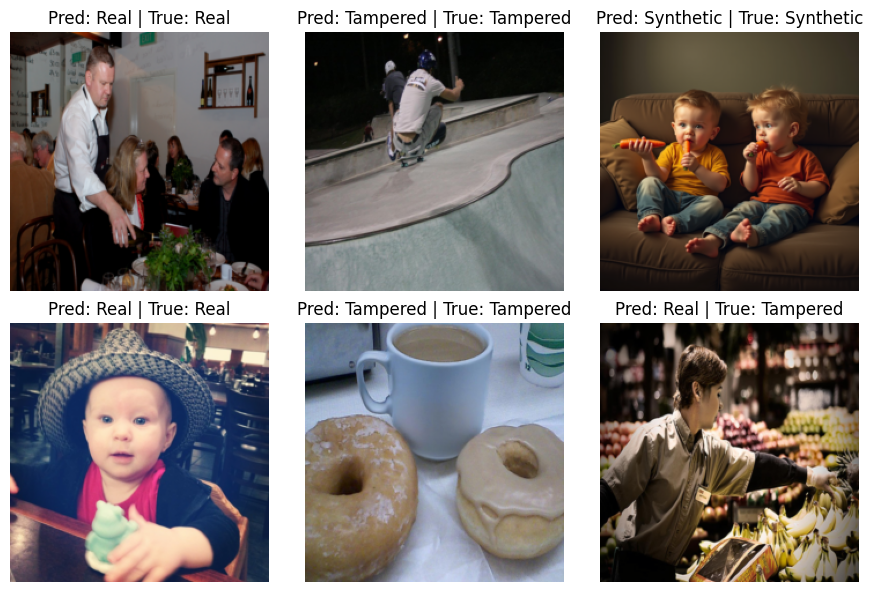

Classification artefacts:
best_model.pth evaluation.json history.json


In [15]:
# First, we save our key results: the best model weights and the training history.
model_path_c = CLASS_RUN_DIR / 'best_model.pth'
history_path_c = CLASS_RUN_DIR / 'history.json'
torch.save(ema_c.state_dict(), model_path_c)

# We save the history dictionary, which contains our loss and accuracy curves, to a JSON file.
with history_path_c.open('w') as fp:
    json.dump({k: v for k, v in history_c.items()}, fp, indent=2)
print('Saved classification model to', model_path_c)

# Now, we'll run our final model over the entire validation set to get predictions for evaluation.
ema_c.eval()
all_preds: list[int] = []
all_labels: list[int] = []

# We disable gradients for this part as we're only doing inference.
with torch.no_grad():
    # We iterate through the validation loader, batch by batch.
    for batch in val_loader_c:
        images = batch['image'].to(CLASS_DEVICE)
        labels = batch['label'].to(CLASS_DEVICE)
        
        # Get the model's predictions.
        logits = ema_c(images)
        preds = logits.argmax(dim=1)
        
        # Collect the predictions and true labels for later comparison.
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

# Using scikit-learn, we generate a detailed classification report (precision, recall, F1-score).
report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
# We also compute the confusion matrix.
cm = confusion_matrix(all_labels, all_preds)

# We'll save both the report and the confusion matrix to a single JSON file for easy access.
(CLASS_RUN_DIR / 'evaluation.json').write_text(
    json.dumps({'classification_report': report, 'confusion_matrix': cm.tolist()}, indent=2)
)
print('Classification macro F1:', report['macro avg']['f1-score'])

# We'll now plot the loss curves to visualize how the model learned over time.
plt.figure(figsize=(8, 4))
plt.plot(history_c['train_loss'], label='Train')
plt.plot(history_c['val_loss'], label='Validation')
plt.title('Classification Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# We do the same for accuracy curves to check for overfitting and see performance trends.
plt.figure(figsize=(8, 4))
plt.plot(history_c['train_acc'], label='Train')
plt.plot(history_c['val_acc'], label='Validation')
plt.title('Classification Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# It's also useful to visualize the learning rate schedule.
plt.figure(figsize=(8, 4))
plt.plot(history_c['lr'])
plt.title('Classification Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.show()

# A heatmap of the confusion matrix gives us a clear view of which classes the model is confusing.
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,     # Show the counts in each cell.
    fmt='d',        # Format as integers.
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Val-set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Finally, let's look at a few qualitative examples to see our model in action.
sample_batch = next(iter(val_loader_c))
images = sample_batch['image'][:6].to(CLASS_DEVICE)
labels = sample_batch['label'][:6]

# Get model predictions for this small batch.
with torch.no_grad():
    logits = ema_c(images)
    preds = logits.argmax(dim=1).cpu()

# We'll display the images with their predicted and true labels.
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, img, pred, label in zip(axes.flatten(), images.cpu(), preds, labels):
    # We must "denormalize" the image to reverse the normalization transform for correct display.
    img_disp = denormalize(img)
    pred_idx = int(pred.item())
    label_idx = int(label.item())
    ax.imshow(img_disp)
    ax.set_title(f"Pred: {CLASS_NAMES[pred_idx]} | True: {CLASS_NAMES[label_idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# To wrap up, we'll list the files created in our run directory to confirm everything was saved.
print('Classification artefacts:')
print(' '.join(sorted(p.name for p in CLASS_RUN_DIR.iterdir())))

## Part B — Segmentation Pipeline

With the classifier complete, we now turn to the second part of our project: segmentation. Our goal here is to localize the specific manipulated pixels within a tampered image. We will follow the same structured playbook we used in Part A: first we will define our configuration, then prepare the data, build the model, and finally, run the training and evaluation loop.

This configuration mirrors the structure from Part A, but we've tailored it for segmentation. We define the number of training samples, the batch size, and the model's architecture. We've also added parameters specific to our new task, such as the weights for our combined Dice and BCE loss functions, which we will use to train the model to produce accurate masks.

In [16]:
SEG_CFG = {
    # Dataset sampling limits plus image/mask resolution for segmentation runs.
    'data': {
        'dataset_name': 'saberzl/SID_Set',      # HF dataset providing paired frames and manipulation masks.
        'image_size': 224,                      # Square resolution after joint resizing/cropping.
        'train_samples': 10000,                # Number of training samples materialised per epoch window.
        'val_samples': 3000,                  # Validation subset size for monitoring overfitting.
        'buffer_multiplier': 4,                 # Extra HF rows to cache so joint transforms stay fast.
    },

    # DataLoader orchestration mirroring the classification workflow for parity.
    'loader': {
        'batch_size': 32,                       # Mini-batch size tuned for mask-heavy tensors.
        'num_workers': 4,                       # Parallel workers (keep modest for joint transforms).
        'shuffle_train': True,                  # Shuffle training batches for randomness.
        'pin_memory': True,                     # Pin CPU buffers to accelerate host->device copies.
        'persistent_workers': False,            # Recycle worker pools when running multiple epochs.
        'prefetch_factor': 2,                   # Number of batches each worker preloads ahead.
    },

    # Lightweight U-Net style architecture knobs used by seg_build_model.
    'model': {
        'out_channels': 1,                      # Binary manipulation mask prediction.
        'dropout': 0.3,                         # Dropout applied in decoder heads.
    },

    # Core optimisation hyperparameters shared with the classification workflow.
    'training': {
        'epochs': 30,                           # Number of epochs over the sampled window.
        'learning_rate': 9.2e-4,                # Base LR fed into the optimiser.
        'grad_clip_norm': 1.9,                  # Gradient norm cap to stabilise mixed precision.
        'ema_decay': 0.995,                     # EMA coefficient for weight averaging.
        'use_amp': True,                        # Enable PyTorch AMP for faster training.
        'loss': {
            'bce_weight': 0.3,                  # Contribution of BCE-with-logits loss.
            'dice_weight': 0.7,                 # Contribution of soft Dice loss.
        },
        'optimizer': {
            'name': 'adamw',                    # Optimiser family (adamw keeps weight decay decoupled).
            'weight_decay': 2e-3,               # L2 penalty promoting smooth masks.
            'betas': (0.9, 0.95),               # Momentum coefficients for AdamW.
        },
        'scheduler': {
            'name': 'onecycle',                 # Scheduler shape (matches classification shorthand).
            'max_lr': 1e-3,                     # Peak LR reached during warm-up.
            'pct_start': 0.3,                   # Portion of cycle spent increasing the LR.
        },
    },

    # Augmentation knobs applied jointly to images and masks for regularisation.
    'augmentation': {
        'enable': True,                         # Master switch for train-time augmentations.
        'horizontal_flip_prob': 0.5,            # Probability of mirroring each pair.
        'color_jitter': {
            'brightness': 0.3,                  # Brightness jitter magnitude.
            'contrast': 0.3,                    # Contrast jitter magnitude.
            'saturation': 0.25,                 # Saturation jitter magnitude.
            'hue': 0.05,                        # Hue jitter magnitude.
        },
        'blur_prob': 0.4,                       # Chance of applying Gaussian blur.
        'blur_sigma': (0.1, 1.5),               # Sigma range for the blur kernel.
        'random_erasing_prob': 0.0,             # Random erasing disabled for masks by default.
    },

    # Evaluation toggles (Dice threshold sweeps + qualitative gallery size).
    'evaluation': {
        'thresholds': [0.25, 0.35, 0.5, 0.65, 0.75],  # Sigmoid cutoffs for Dice/IoU reporting.
        'gallery_examples': 6,                   # Number of qualitative examples to display.
    },

    # Global run options for reproducibility and artefact storage.
    'seed': 42,
    'output_root': Path('project_outputs_segmentation'),
}


Just as we did for the classification pipeline, we prepare our experiment environment. In this cell, we create the output directory, set a global random seed for reproducibility, and generate a unique ID for this specific run. This ensures that every execution is self-contained and its results are traceable.

In [17]:
# First, we create the main output directory and set the random seed for reproducibility.
SEG_CFG['output_root'].mkdir(parents=True, exist_ok=True)
cls_set_seed(SEG_CFG['seed'])

# Next, we select our compute device, generate a unique ID, and create a dedicated folder for this run.
SEG_DEVICE = cls_device()
SEG_RUN_ID = cls_timestamp()
SEG_RUN_DIR = SEG_CFG['output_root'] / SEG_RUN_ID
SEG_RUN_DIR.mkdir(parents=True, exist_ok=True)

# Finally, we print the full configuration and key paths to confirm our settings for this run.
print('Segmentation configuration:')
print(json.dumps(_json_ready(SEG_CFG), indent=2))
print('Device:', SEG_DEVICE)
print('Output folder:', SEG_RUN_DIR)

Segmentation configuration:
{
  "data": {
    "dataset_name": "saberzl/SID_Set",
    "image_size": 224,
    "train_samples": 10000,
    "val_samples": 3000,
    "buffer_multiplier": 4
  },
  "loader": {
    "batch_size": 32,
    "num_workers": 4,
    "shuffle_train": true,
    "pin_memory": true,
    "persistent_workers": false,
    "prefetch_factor": 2
  },
  "model": {
    "out_channels": 1,
    "dropout": 0.3
  },
  "training": {
    "epochs": 30,
    "learning_rate": 0.00092,
    "grad_clip_norm": 1.9,
    "ema_decay": 0.995,
    "use_amp": true,
    "loss": {
      "bce_weight": 0.3,
      "dice_weight": 0.7
    },
    "optimizer": {
      "name": "adamw",
      "weight_decay": 0.002,
      "betas": [
        0.9,
        0.95
      ]
    },
    "scheduler": {
      "name": "onecycle",
      "max_lr": 0.001,
      "pct_start": 0.3
    }
  },
  "augmentation": {
    "enable": true,
    "horizontal_flip_prob": 0.5,
    "color_jitter": {
      "brightness": 0.3,
      "contrast": 0.3

A key challenge in segmentation is ensuring that any geometric augmentations, like cropping or flipping, are applied identically to both the image and its mask. To solve this, we created the SegmentationJointTransform class, which handles these shared operations. The build_segmentation_transforms function then uses this class and adds separate photometric augmentations (like color changes) that only apply to the image, giving us a complete data augmentation pipeline.

In [18]:
# We use this class to apply the same geometric augmentations (like cropping and flipping)
# to both an image and its mask. This ensures they remain aligned.
class SegmentationJointTransform:
    def __init__(self, augment_cfg: dict, image_size: int, *, is_train: bool):
        # We store the configuration and a flag for training vs. validation behavior.
        self.cfg = augment_cfg or {}
        self.image_size = image_size
        self.is_train = is_train

    def _resize_pair(self, image, mask):
        # We resize the image and mask to the target size.
        # - For the image, we use bilinear interpolation to keep it smooth.
        # - For the mask, we use nearest-neighbor to preserve its binary edges.
        resized_image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
        )
        resized_mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST,
        )
        return resized_image, resized_mask

    def __call__(self, image, mask):
        # For validation or if augmentations are off, we only apply a resize.
        if not self.is_train or not self.cfg.get('enable', False):
            return self._resize_pair(image, mask)

        # For training, we apply a random resized crop.
        if self.cfg.get('random_resized_crop_scale'):
            # First, we get one set of random crop parameters.
            scale = self.cfg['random_resized_crop_scale']
            ratio = self.cfg.get('random_resized_crop_ratio', (0.75, 1.33))
            i, j, h, w = T.RandomResizedCrop.get_params(image, scale=scale, ratio=ratio)

            # Then, we apply those exact parameters to both the image and the mask.
            image = TF.resized_crop(
                image, top=i, left=j, height=h, width=w,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )
            mask = TF.resized_crop(
                mask, top=i, left=j, height=h, width=w,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.NEAREST,
            )
        else:
            # If cropping is off, we fall back to a resize.
            image, mask = self._resize_pair(image, mask)

        # We apply the horizontal flip to both the image and mask.
        if self.cfg.get('horizontal_flip_prob', 0) > random.random():
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        return image, mask


# We use this factory function to create three transform pipelines from our configuration.
def build_segmentation_transforms(cfg: dict, *, is_train: bool):
    """
    Returns a tuple of three transforms:
    1. joint_transform: Handles geometric changes (cropping, flipping) for the image-mask pair.
    2. image_transform:  Handles photometric changes (color, blur) and normalization for the image.
    3. mask_transform:   Handles converting the mask to a tensor.
    """
    # We create the joint transform object for geometric changes.
    joint_transform = SegmentationJointTransform(
        cfg['augmentation'], cfg['data']['image_size'], is_train=is_train
    )

    # We define transforms that apply only to the image.
    image_ops = [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]

    # During training, we insert photometric augmentations into the image pipeline.
    if is_train and cfg['augmentation'].get('enable', False):
        aug_cfg = cfg['augmentation']
        cj = aug_cfg.get('color_jitter', {})
        # We add color jitter to make the model robust to lighting changes.
        if any(cj.get(k, 0) > 0 for k in ('brightness', 'contrast', 'saturation', 'hue')):
            image_ops.insert(1, T.ColorJitter(**cj))
        
        # We add blur to simulate camera focus or compression artifacts.
        if aug_cfg.get('blur_prob', 0) > 0:
            blur_transform = T.GaussianBlur(
                kernel_size=3, sigma=aug_cfg.get('blur_sigma', (0.1, 1.5))
            )
            image_ops.insert(1, T.RandomApply([blur_transform], p=aug_cfg['blur_prob']))
        
        # We add random erasing to prevent the model from overfitting to specific features.
        if aug_cfg.get('random_erasing_prob', 0) > 0:
            image_ops.append(T.RandomErasing(
                p=aug_cfg['random_erasing_prob'],
                scale=(0.02, 0.2),
                ratio=(0.3, 3.3),
            ))

    # For the mask, we only convert it to a tensor.
    mask_ops = [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
    ]

    # We return the joint transformer and the two composed pipelines.
    return joint_transform, T.Compose(image_ops), T.Compose(mask_ops)

This SegmentationDataset class acts as the bridge between our Hugging Face data and PyTorch. Its job is to take a raw data sample, apply the transforms we just created, and return a pair of tensors (image and mask) ready for the model. We also binarize the mask by applying a > 0.5 threshold. We found this step necessary to clean up anti-aliasing artifacts introduced by resizing, ensuring the model trains on a clean binary target.

In [19]:
class SegmentationDataset(Dataset):
    """Map-style dataset that emits dicts with `image` and `mask` tensors."""

    def __init__(self, dataset, *, joint_transform, image_transform, mask_transform):
        self.dataset = dataset
        self.joint_transform = joint_transform
        self.image_transform = image_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx: int) -> dict:
        # We load a sample and convert the image to RGB and the mask to grayscale.
        sample = self.dataset[idx]
        image = sample['image'].convert('RGB')
        mask = sample['mask']
        if mask is None:
            raise ValueError('Filtered dataset still contains a sample without mask data.')
        mask = mask.convert('L')

        # We apply geometric transforms to the pair, then image- and mask-specific transforms.
        image, mask = self.joint_transform(image, mask)
        image_tensor = self.image_transform(image)
        mask_tensor = self.mask_transform(mask)

        # We ensure the mask has a channel dimension and is binarized for the loss function.
        if mask_tensor.ndim == 2:
            mask_tensor = mask_tensor.unsqueeze(0)
        elif mask_tensor.ndim == 3 and mask_tensor.shape[0] > 1:
            mask_tensor = mask_tensor[:1]
        mask_tensor = (mask_tensor > 0.5).float()
        
        return {'image': image_tensor, 'mask': mask_tensor}

Here, we bring all our data preparation steps together. This function fetches the dataset from Hugging Face, filters it to keep only the 'tampered' samples that have a ground-truth mask, and then wraps everything in PyTorch DataLoader instances. These loaders will efficiently feed batches of images and masks to our model during training.

In [20]:
# We create a filter to keep only tampered samples (label=2) that have a mask.
def _filter_tampered_with_masks(example):
    mask = example.get('mask')
    label = int(example.get('label', 2))
    return mask is not None and label == 2


# We build the data loaders for the segmentation task.
def build_segmentation_loaders(cfg: dict) -> tuple[DataLoader, DataLoader, dict]:
    data_cfg = cfg['data']
    dataset_name = data_cfg['dataset_name']
    # We load extra rows to account for items removed by our filter.
    buffer = max(1, data_cfg.get('buffer_multiplier', 3))

    def _materialise(split: str, requested: int):
        # We load, filter, shuffle, and truncate a dataset split.
        slice_str = split
        if requested:
            slice_str = f"{split}[:{requested * buffer}]"
        ds = load_dataset(dataset_name, split=slice_str)
        # We apply our filter to keep only tampered frames with masks.
        ds = ds.filter(_filter_tampered_with_masks)
        if len(ds) == 0:
            raise RuntimeError(f'No {split} samples with masks were found. Adjust buffer_multiplier or inspect the dataset download.')
        # We shuffle the data for reproducible sampling.
        ds = ds.shuffle(seed=cfg['seed'])
        if requested and len(ds) > requested:
            # We trim the dataset to the requested size.
            ds = ds.select(range(requested))
        return ds

    hf_train = _materialise('train', data_cfg['train_samples'])
    hf_val = _materialise('validation', data_cfg['val_samples'])

    # We build the transform pipelines for the training and validation sets.
    joint_train, img_train_tf, mask_train_tf = build_segmentation_transforms(cfg, is_train=True)
    joint_val, img_val_tf, mask_val_tf = build_segmentation_transforms(cfg, is_train=False)

    train_dataset = SegmentationDataset(
        hf_train, joint_transform=joint_train, image_transform=img_train_tf, mask_transform=mask_train_tf
    )
    val_dataset = SegmentationDataset(
        hf_val, joint_transform=joint_val, image_transform=img_val_tf, mask_transform=mask_val_tf
    )

    loader_kwargs = {
        'batch_size': cfg['loader']['batch_size'],
        'num_workers': cfg['loader']['num_workers'],
        'pin_memory': cfg['loader']['pin_memory'],
    }
    # We add worker-specific settings only if using multiple workers.
    if cfg['loader']['num_workers'] > 0:
        loader_kwargs['prefetch_factor'] = cfg['loader']['prefetch_factor']
        loader_kwargs['persistent_workers'] = cfg['loader']['persistent_workers']

    train_loader = DataLoader(train_dataset, shuffle=cfg['loader']['shuffle_train'], **loader_kwargs)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)

    # We bundle the raw data and transforms for later inspection.
    context = {
        'raw_train': hf_train,
        'aug_transforms': (joint_train, img_train_tf, mask_train_tf),
        'eval_transforms': (joint_val, img_val_tf, mask_val_tf),
    }
    return train_loader, val_loader, context


train_loader_s, val_loader_s, SEG_DATA_CONTEXT = build_segmentation_loaders(SEG_CFG)
print(f"Segmentation training batches: {len(train_loader_s)} | validation batches: {len(val_loader_s)}")

Segmentation training batches: 313 | validation batches: 94


Analyzing Training Set Masks (Augmented View)...


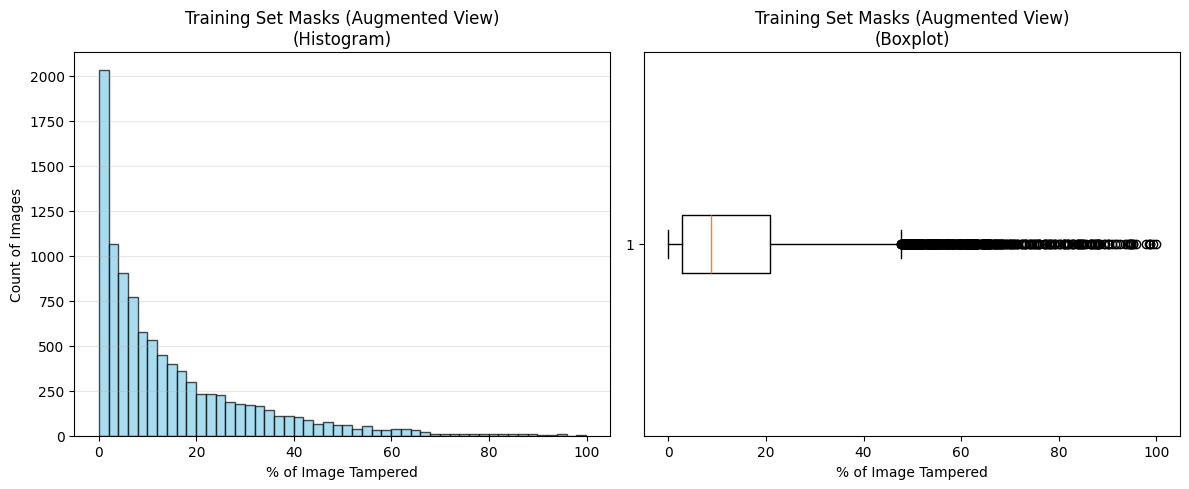

--- Training Set Masks (Augmented View) Stats ---
Total Images:      10000
Mean Tampered %:   14.64%
Median Tampered %: 8.78%
Min Tampered %:    0.0000%
Max Tampered %:    99.88%
Images with < 1% tampering: 1310 (13.1%)
Analyzing Training Set Masks (Raw Full Frames)...


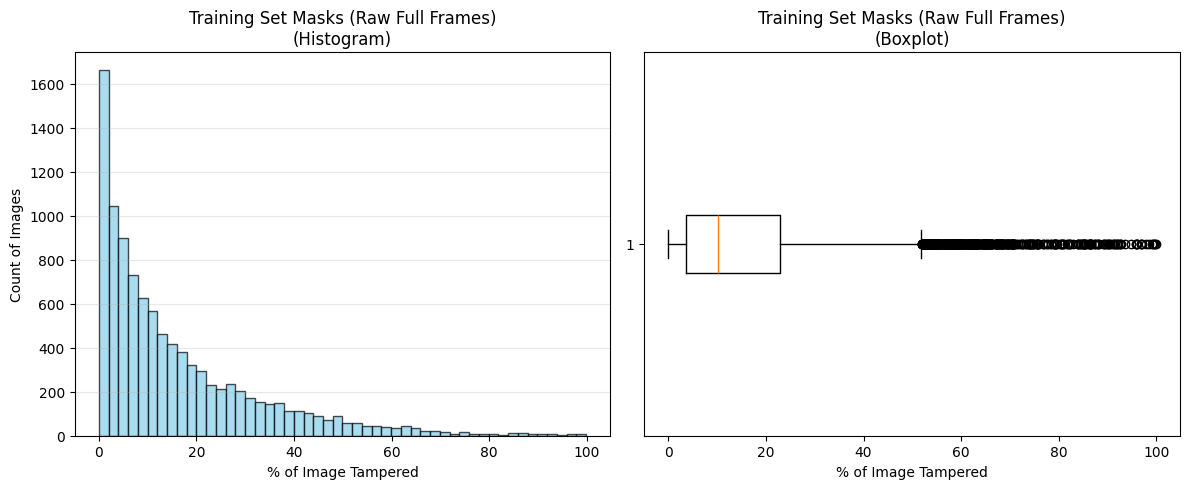

--- Training Set Masks (Raw Full Frames) Stats ---
Total Images:      10000
Mean Tampered %:   15.97%
Median Tampered %: 10.11%
Min Tampered %:    0.0232%
Max Tampered %:    99.86%
Images with < 1% tampering: 961 (9.6%)


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

def _summarize_mask_stats(ratios: list[float], title: str) -> None:
    ratios = np.array(ratios, dtype=np.float32)
    if ratios.size == 0:
        raise ValueError('No mask ratios were collected; check the provided data source.')

    # --- Plotting ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(ratios, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel('% of Image Tampered')
    plt.ylabel('Count of Images')
    plt.title(f'{title}\n(Histogram)')
    plt.grid(axis='y', alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.boxplot(ratios, vert=False)
    plt.xlabel('% of Image Tampered')
    plt.title(f'{title}\n(Boxplot)')

    plt.tight_layout()
    plt.show()

    # --- Statistics ---
    print(f"--- {title} Stats ---")
    print(f"Total Images:      {len(ratios)}")
    print(f"Mean Tampered %:   {np.mean(ratios):.2f}%")
    print(f"Median Tampered %: {np.median(ratios):.2f}%")
    print(f"Min Tampered %:    {np.min(ratios):.4f}%")
    print(f"Max Tampered %:    {np.max(ratios):.2f}%")
    tiny_count = np.sum(ratios < 1.0)
    print(f"Images with < 1% tampering: {tiny_count} ({tiny_count / len(ratios) * 100:.1f}%)")


def analyze_mask_distribution(*, loader=None, raw_dataset=None, title="Tampered Pixel Distribution"):
    """Report tamper coverage statistics for either an augmented loader or the raw dataset."""
    if loader is None and raw_dataset is None:
        raise ValueError('Pass either a DataLoader via `loader=` or a raw dataset via `raw_dataset=`.')

    tampered_ratios: list[float] = []
    print(f"Analyzing {title}...")

    if loader is not None:
        # Iterate through the loader to see exactly what the model sees (after resizing/cropping)
        for batch in tqdm(loader, leave=False):
            masks = batch['mask']
            for i in range(masks.shape[0]):
                mask_flat = masks[i].view(-1)
                tampered_ratios.append(mask_flat.mean().item() * 100.0)
    else:
        # Operate on the untouched Hugging Face records to measure "true" tampering coverage.
        for record in tqdm(raw_dataset, leave=False):
            mask_obj = record['mask']
            if hasattr(mask_obj, 'convert'):
                mask_obj = mask_obj.convert('L')
            mask_np = np.asarray(mask_obj)
            if mask_np.ndim == 3:
                mask_np = mask_np.mean(axis=-1)
            mask_bin = mask_np > 0
            tampered_ratios.append(mask_bin.mean() * 100.0)

    _summarize_mask_stats(tampered_ratios, title)


# Run the analysis on both augmented (what the model sees) and raw masks.
analyze_mask_distribution(loader=train_loader_s, title="Training Set Masks (Augmented View)")
analyze_mask_distribution(raw_dataset=SEG_DATA_CONTEXT['raw_train'], title="Training Set Masks (Raw Full Frames)")

Before we start training, we will visually inspect our data pipeline. This allows us to confirm that our geometric augmentations are correctly applied to both the image and the mask, ensuring they stay aligned. The final column shows the augmented image with the transformed mask overlaid, which is exactly what our model will see during training.

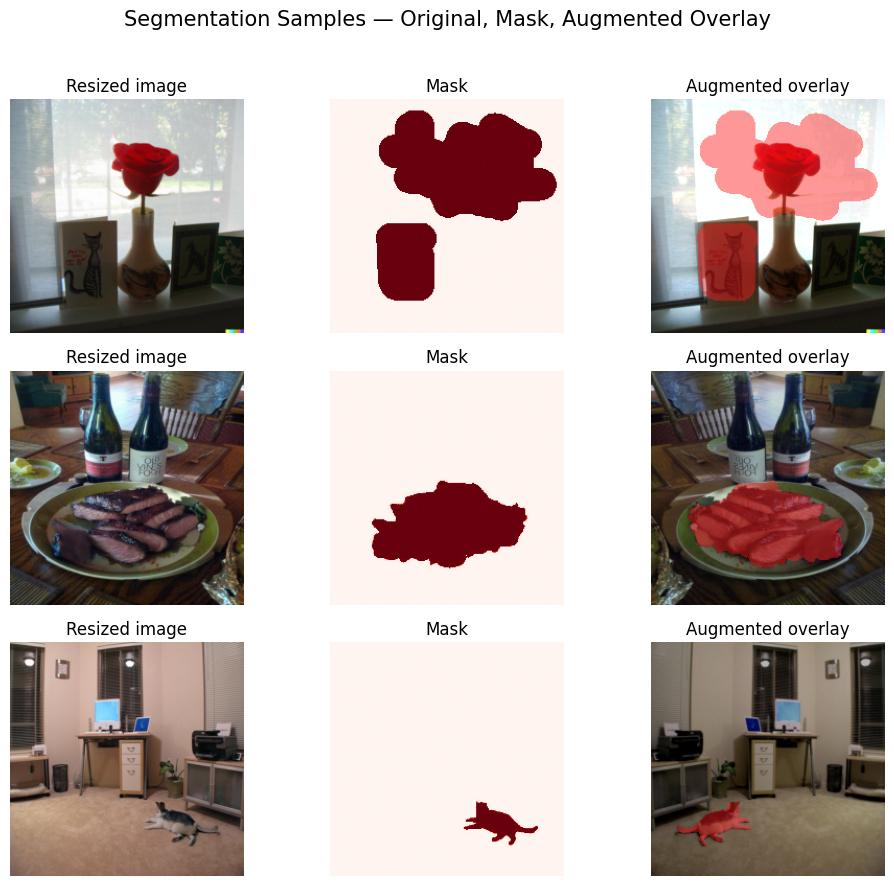

In [22]:
# Convert a mask tensor or array to a 2D NumPy array for plotting.
def to_display_mask(mask_arr: np.ndarray) -> np.ndarray:
    try:
        mask_arr = mask_arr.detach().cpu().numpy()
    except AttributeError:
        mask_arr = np.asarray(mask_arr)

    if mask_arr.ndim == 3:
        reduce_axis = 0 if mask_arr.shape[0] <= mask_arr.shape[-1] else mask_arr.ndim - 1
        mask_arr = mask_arr.mean(axis=reduce_axis)

    return np.squeeze(mask_arr)


# Blend a mask onto an image to create a colored overlay.
def mask_overlay(image_np: np.ndarray, mask_np: np.ndarray, color=(1.0, 0.1, 0.1), alpha: float = 0.45):
    overlay = image_np.copy()
    flat_mask = to_display_mask(mask_np)
    mask_bool = flat_mask > 0.5
    overlay[mask_bool] = (1 - alpha) * overlay[mask_bool] + alpha * np.array(color)
    return overlay


# Set up a grid to compare original samples with their augmented versions.
num_rows = 3
raw_train = SEG_DATA_CONTEXT['raw_train']
orig_joint, orig_img_tf, orig_mask_tf = SEG_DATA_CONTEXT['eval_transforms']
aug_joint, aug_img_tf, aug_mask_tf = SEG_DATA_CONTEXT['aug_transforms']

fig, axes = plt.subplots(num_rows, 3, figsize=(10, num_rows * 3))
fig.suptitle('Segmentation Samples — Original, Mask, Augmented Overlay', fontsize=15)

for row in range(num_rows):
    # Get a raw image and mask from the dataset.
    record = raw_train[row]
    pil_image = record['image'].convert('RGB')
    pil_mask = record['mask']

    # Apply both evaluation (resize-only) and training (augmented) transforms.
    base_img, base_mask = orig_joint(pil_image, pil_mask)
    aug_img, aug_mask = aug_joint(pil_image, pil_mask)

    # Convert the tensors back to displayable NumPy arrays.
    base_img_t = orig_img_tf(base_img)
    aug_img_t = aug_img_tf(aug_img)
    base_img_np = denormalize(base_img_t)
    aug_img_np = denormalize(aug_img_t)
    base_mask_np = to_display_mask(orig_mask_tf(base_mask))
    aug_mask_np = to_display_mask(aug_mask_tf(aug_mask))

    # Plot the resized image, the original mask, and the augmented overlay.
    axes[row, 0].imshow(base_img_np)
    axes[row, 0].set_title('Resized image')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(base_mask_np, cmap='Reds', aspect='equal')
    axes[row, 1].set_title('Mask')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(mask_overlay(aug_img_np, aug_mask_np))
    axes[row, 2].set_title('Augmented overlay')
    axes[row, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

For our segmentation task, we use a U-Net architecture with a pre-trained ResNet-50 backbone as its encoder. This approach, often called a "Res-UNet," combines the feature extraction capabilities of a ResNet, learned from the ImageNet dataset, with the U-Net's decoder structure for pixel-level localization. By using a pre-trained encoder, our model starts with an understanding of general image features, which improves performance and training efficiency. The decoder then uses skip connections to merge these high-level features with fine-grained spatial information to produce the single-channel segmentation mask.

In [23]:
# A standard convolutional block: Conv -> BatchNorm -> ReLU.
class ConvBNReLU(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        # Dropout is only used in the decoder.
        if dropout > 0:
            layers.insert(1, nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

# The decoder's upsampling block.
class UpBlock(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__()
        # Upsample the feature map and then apply the convolutional block.
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = ConvBNReLU(in_channels + skip_channels, out_channels, dropout)

    def forward(self, x, skip):
        x = self.up(x)
        # Concatenate with the skip connection from the encoder.
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

# A U-Net architecture using a pre-trained ResNet-50 as the encoder.
class TamperUNet(nn.Module):
    def __init__(self, *, out_channels: int, dropout: float):
        super().__init__()
        # Load a pre-trained ResNet-50 backbone.
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        
        # Define encoder stages from the ResNet layers.
        # We separate the first conv/relu block from the first maxpool
        # to capture a high-resolution feature map for a skip connection.
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.pool0 = backbone.maxpool
        
        self.enc1 = backbone.layer1
        self.enc2 = backbone.layer2
        self.enc3 = backbone.layer3
        self.enc4 = backbone.layer4

        # Define decoder blocks that correspond to the encoder's feature maps.
        self.up4 = UpBlock(2048, 1024, 512, dropout)
        self.up3 = UpBlock(512, 512, 256, dropout)
        self.up2 = UpBlock(256, 256, 128, dropout)
        self.up1 = UpBlock(128, 64, 64, dropout)
        
        # The final output layer produces the raw segmentation logits.
        self.head = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Pass input through the encoder, saving feature maps for skip connections.
        s0 = self.enc0(x)
        s1_input = self.pool0(s0)
        
        s1 = self.enc1(s1_input)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        
        # Pass features through the decoder, merging with skip connections.
        d4 = self.up4(s4, s3)
        d3 = self.up3(d4, s2)
        d2 = self.up2(d3, s1)
        d1 = self.up1(d2, s0)
        
        # Produce the final output logits.
        logits = self.head(d1)
        
        # Upsample the output to match the input image size for the loss function.
        return F.interpolate(logits, size=x.shape[-2:], mode='bilinear', align_corners=False)

For our loss, we combine Binary Cross-Entropy (BCE) with a soft Dice loss. BCE evaluates pixel-wise accuracy, while Dice loss is better at handling class imbalance, such as small tampered regions in a large image. We use the weights in SEG_CFG to balance their contributions. The remaining helpers in this cell build our optimizer and scheduler, just as they did in the classification pipeline.

In [24]:
# Calculate the soft Dice loss, which is differentiable and used for training.
def seg_soft_dice_loss(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    targets = targets.float()
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    denominator = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (denominator + eps)
    return 1 - dice.mean()

# Calculate the hard Dice score on binarized predictions, used for evaluation.
def seg_binary_dice(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    preds = (torch.sigmoid(logits) > 0.5).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    denominator = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return ((2 * intersection + eps) / (denominator + eps)).mean()

# Combine BCE and Dice loss according to the weights specified in the config.
def seg_loss_fn(logits, targets, loss_cfg):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice_loss = seg_soft_dice_loss(logits, targets)
    total = loss_cfg['bce_weight'] * bce + loss_cfg['dice_weight'] * dice_loss
    return total, {'bce': bce.item(), 'dice_component': 1 - dice_loss.item(), 'dice_loss': dice_loss.item()}

# A factory function to build the optimizer from the configuration.
def seg_build_optimizer(model: nn.Module, cfg: dict):
    opt_cfg = cfg['training']['optimizer']
    lr = cfg['training']['learning_rate']
    name = opt_cfg['name'].lower()
    if name == 'adamw':
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=opt_cfg.get('weight_decay', 0.0), betas=opt_cfg.get('betas', (0.9, 0.999)))
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=lr, weight_decay=opt_cfg.get('weight_decay', 0.0), betas=opt_cfg.get('betas', (0.9, 0.999)))
    if name == 'sgd':
        return optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=opt_cfg.get('momentum', 0.9),
            weight_decay=opt_cfg.get('weight_decay', 0.0),
            nesterov=opt_cfg.get('nesterov', False),
        )
    raise ValueError(f"Unsupported optimizer '{opt_cfg['name']}'.")

# A factory function to build the learning rate scheduler from the configuration.
def seg_build_scheduler(optimizer, cfg: dict, steps_per_epoch: int):
    sched_cfg = cfg['training']['scheduler']
    name = (sched_cfg.get('name') or '').lower()
    if not name or name == 'none':
        return None, 'epoch'
    if name == 'cosine':
        t_max = sched_cfg.get('t_max') or cfg['training']['epochs']
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max)
        return scheduler, 'epoch'
    if name == 'onecycle':
        if steps_per_epoch <= 0:
            raise ValueError('OneCycleLR requires a positive number of steps per epoch.')
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=sched_cfg.get('max_lr', cfg['training']['learning_rate'] * 10),
            epochs=cfg['training']['epochs'],
            steps_per_epoch=steps_per_epoch,
            pct_start=sched_cfg.get('pct_start', 0.3),
            div_factor=25.0,
            final_div_factor=1000.0,
        )
        return scheduler, 'batch'
    raise ValueError(f"Scheduler '{sched_cfg['name']}' is not supported in this notebook.")

With all the components defined, we now instantiate everything needed for training. We create the U-Net model, the optimizer, the learning rate scheduler, and the GradScaler for mixed-precision training. We also create a separate Exponential Moving Average (EMA) model, which will hold a running average of the trained model's weights to improve generalization.

In [25]:
# Instantiate the U-Net model, optimizer, and scheduler from the configuration.
SEG_MODEL = TamperUNet(
    out_channels=SEG_CFG['model']['out_channels'],
    dropout=SEG_CFG['model']['dropout'],
).to(SEG_DEVICE)

SEG_OPTIMIZER = seg_build_optimizer(SEG_MODEL, SEG_CFG)
steps_per_epoch = max(1, len(train_loader_s))
SEG_SCHEDULER, SEG_SCHED_MODE = seg_build_scheduler(SEG_OPTIMIZER, SEG_CFG, steps_per_epoch)

# Set up the scaler for automatic mixed-precision (AMP) training.
SEG_SCALER = amp.GradScaler(enabled=SEG_CFG['training']['use_amp'])

# Syncs buffers (like BatchNorm stats) from the training model to the EMA model.
def update_ema_buffers(ema_model, model):
    for name, buf in model.named_buffers():
        ema_model.state_dict()[name].copy_(buf)

# Set up the Exponential Moving Average (EMA) model for better generalization.
SEG_EMA = TamperUNet(
    out_channels=SEG_CFG['model']['out_channels'],
    dropout=SEG_CFG['model']['dropout'],
).to(SEG_DEVICE)

# Initialize EMA weights to match the training model.
SEG_EMA.load_state_dict(SEG_MODEL.state_dict())

# Disable gradients for the EMA model as it's only used for evaluation.
for param in SEG_EMA.parameters():
    param.requires_grad_(False)

# Initialize containers for tracking training history and saving the best model.
SEG_HISTORY = defaultdict(list)
SEG_BEST_PATH = SEG_RUN_DIR / 'best_model.pth'
BEST_SEG_DICE = -float('inf')

This training loop follows the same pattern as our classification loop. For each epoch, we iterate through the training data, calculate the combined BCE and Dice loss, and update the model's weights. We then run a validation pass to measure performance on unseen data and save the model weights that achieve the best validation Dice score.

In [26]:
for epoch in range(1, SEG_CFG['training']['epochs'] + 1):
    # Set the model to training mode for the new epoch.
    SEG_MODEL.train()
    train_loss = 0.0
    train_dice = 0.0
    train_bce = 0.0
    batches = 0
    grad_norm_acc = 0.0

    pbar = tqdm(train_loader_s, desc=f"Seg Epoch {epoch}/{SEG_CFG['training']['epochs']}")
    for batch in pbar:
        images = batch['image'].to(SEG_DEVICE)
        masks = batch['mask'].to(SEG_DEVICE)

        SEG_OPTIMIZER.zero_grad(set_to_none=True)
        # We run the forward pass using automatic mixed precision.
        with amp.autocast(device_type=SEG_DEVICE.type, enabled=SEG_CFG['training']['use_amp']):
            logits = SEG_MODEL(images)
            loss, breakdown = seg_loss_fn(logits, masks, SEG_CFG['training']['loss'])
        
        # We scale the loss, run the backward pass, and update the weights.
        SEG_SCALER.scale(loss).backward()
        if SEG_CFG['training']['grad_clip_norm'] > 0:
            SEG_SCALER.unscale_(SEG_OPTIMIZER)
            grad_norm = torch.nn.utils.clip_grad_norm_(SEG_MODEL.parameters(), SEG_CFG['training']['grad_clip_norm'])
        else:
            SEG_SCALER.unscale_(SEG_OPTIMIZER)
            grads = [p.grad.detach().norm(2) for p in SEG_MODEL.parameters() if p.grad is not None]
            grad_norm = torch.linalg.vector_norm(torch.stack(grads)) if grads else torch.tensor(0.0)
        SEG_SCALER.step(SEG_OPTIMIZER)
        SEG_SCALER.update()

        # We update the EMA model's weights after each batch.
        ema_decay = SEG_CFG['training']['ema_decay']
        for ema_param, param in zip(SEG_EMA.parameters(), SEG_MODEL.parameters()):
            ema_param.data.mul_(ema_decay).add_(param.data, alpha=1 - ema_decay)

        if SEG_SCHEDULER and SEG_SCHED_MODE == 'batch':
            SEG_SCHEDULER.step()

        # Accumulate metrics for this training batch.
        with torch.no_grad():
            dice_score = seg_binary_dice(logits, masks).item()
        train_loss += loss.item()
        train_dice += dice_score
        train_bce += breakdown['bce']
        grad_norm_acc += float(grad_norm)
        batches += 1
        pbar.set_postfix({'loss': f"{loss.item():.3f}", 'dice': f"{dice_score:.3f}"})

    if SEG_SCHEDULER and SEG_SCHED_MODE == 'epoch':
        SEG_SCHEDULER.step()

    # We sync the EMA model's buffers (like BatchNorm stats) at the end of the epoch.
    update_ema_buffers(SEG_EMA, SEG_MODEL)

    train_loss /= max(1, batches)
    train_dice /= max(1, batches)
    train_bce /= max(1, batches)
    grad_norm_acc /= max(1, batches)

    # --- Validation ---
    SEG_EMA.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_batches = 0
    with torch.no_grad():
        for batch in val_loader_s:
            images = batch['image'].to(SEG_DEVICE)
            masks = batch['mask'].to(SEG_DEVICE)
            
            # We use the EMA model for validation as it often generalizes better.
            logits = SEG_EMA(images)
            
            loss, _ = seg_loss_fn(logits, masks, SEG_CFG['training']['loss'])
            val_loss += loss.item()
            val_dice += seg_binary_dice(logits, masks).item()
            val_batches += 1
    val_loss /= max(1, val_batches)
    val_dice /= max(1, val_batches)

    # Log the metrics for the completed epoch.
    SEG_HISTORY['train_loss'].append(train_loss)
    SEG_HISTORY['val_loss'].append(val_loss)
    SEG_HISTORY['train_dice'].append(train_dice)
    SEG_HISTORY['val_dice'].append(val_dice)
    SEG_HISTORY['grad_norm'].append(grad_norm_acc)
    SEG_HISTORY['bce_component'].append(train_bce)
    SEG_HISTORY['lr'].append(SEG_OPTIMIZER.param_groups[0]['lr'])

    print(f"Epoch {epoch}: loss {train_loss:.4f}/{val_loss:.4f} | dice {train_dice:.4f}/{val_dice:.4f} | grad {grad_norm_acc:.3f}")

    # If this model is the best so far, we save its weights.
    if val_dice > BEST_SEG_DICE:
        BEST_SEG_DICE = val_dice
        torch.save(SEG_EMA.state_dict(), SEG_BEST_PATH)
        print(f"  ✔ Saved new best EMA weights (Dice={val_dice:.4f})")

Seg Epoch 1/30: 100%|██████████| 313/313 [00:58<00:00,  5.40it/s, loss=0.571, dice=0.583]


Epoch 1: loss 0.6590/0.7506 | dice 0.4315/0.2642 | grad 0.600
  ✔ Saved new best EMA weights (Dice=0.2642)


Seg Epoch 2/30: 100%|██████████| 313/313 [00:52<00:00,  6.02it/s, loss=0.475, dice=0.631]


Epoch 2: loss 0.5705/0.7140 | dice 0.5174/0.4363 | grad 0.565
  ✔ Saved new best EMA weights (Dice=0.4363)


Seg Epoch 3/30: 100%|██████████| 313/313 [00:52<00:00,  6.01it/s, loss=0.578, dice=0.369]


...

Epoch 28: loss 0.1895/0.2701 | dice 0.7912/0.7070 | grad 0.409


Seg Epoch 29/30: 100%|██████████| 313/313 [00:52<00:00,  5.98it/s, loss=0.211, dice=0.763]


Epoch 29: loss 0.1860/0.2703 | dice 0.7951/0.7066 | grad 0.386


Seg Epoch 30/30: 100%|██████████| 313/313 [00:51<00:00,  6.08it/s, loss=0.131, dice=0.883]


Epoch 30: loss 0.1846/0.2694 | dice 0.7965/0.7077 | grad 0.408


With training complete, we now evaluate our best-performing model on the validation set. We load the best saved weights from the EMA model and generate a comprehensive set of artifacts. This includes saving the final metrics to a JSON file and creating several plots: training curves, a threshold sweep to analyze performance, and a gallery of our model's best and worst predictions to provide qualitative insight.

Saved segmentation history to project_outputs_segmentation/20251128T122952Z/history.json
Segmentation evaluation saved to project_outputs_segmentation/20251128T122952Z/evaluation.json
Mean Dice: 0.6949 | Mean IoU: 0.6003


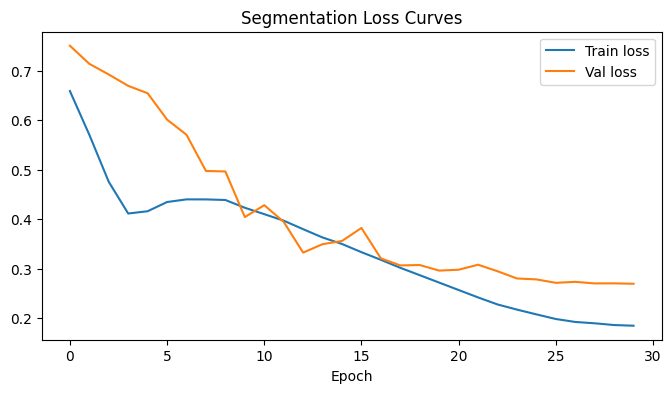

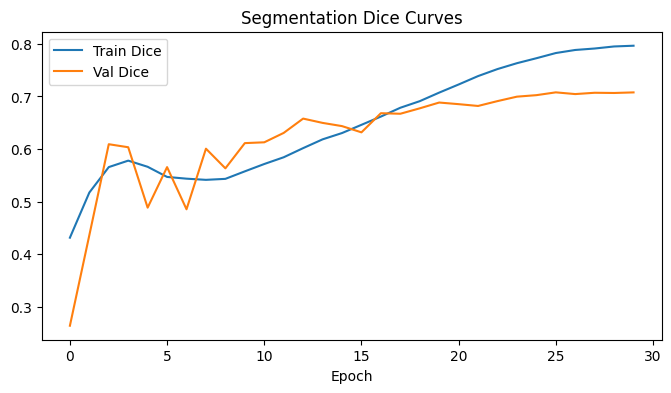

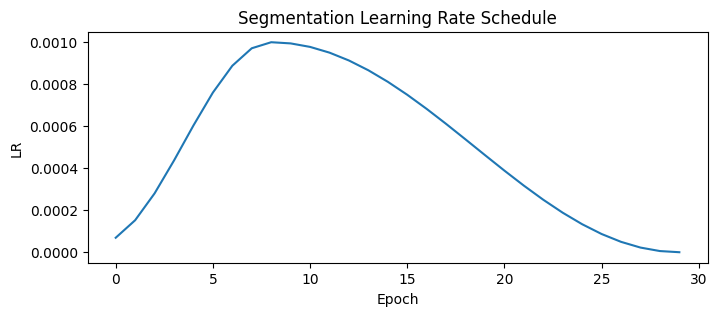

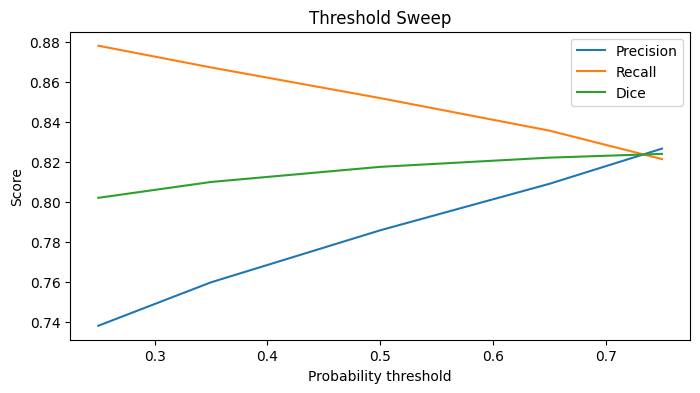

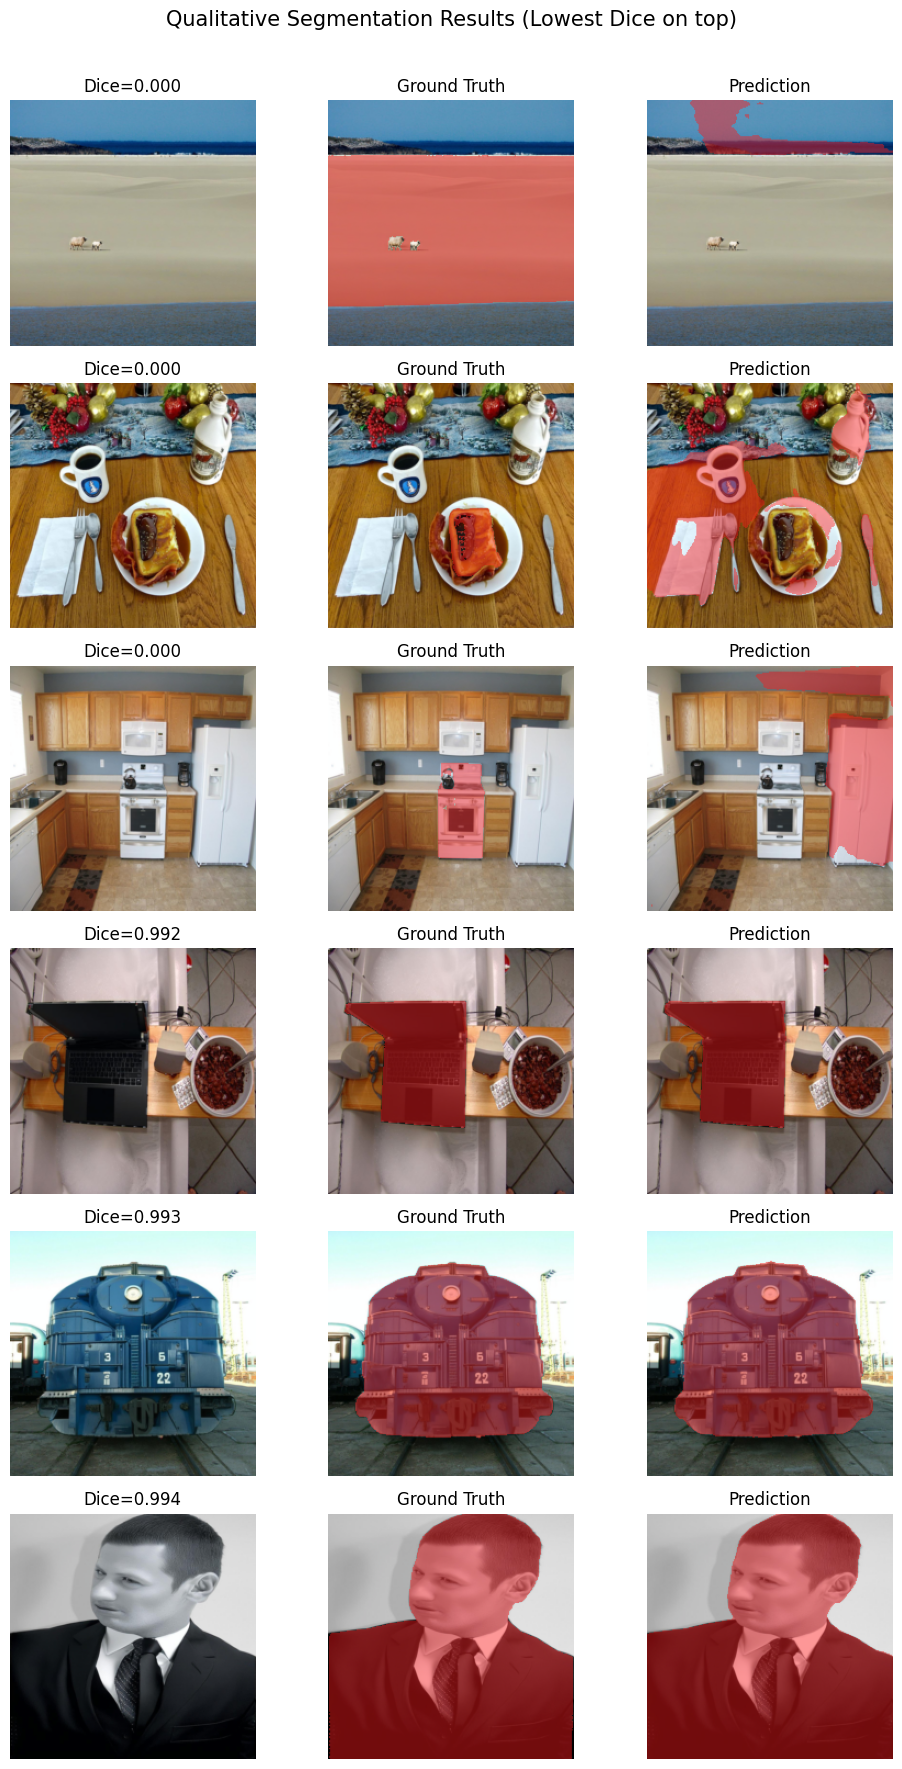

Segmentation artefacts:
 - best_model.pth
 - evaluation.json
 - history.json


In [27]:
# First, we save the training history to a JSON file.
history_path_s = SEG_RUN_DIR / 'history.json'
with history_path_s.open('w') as fp:
    json.dump({k: [float(x) for x in v] for k, v in SEG_HISTORY.items()}, fp, indent=2)
print('Saved segmentation history to', history_path_s)

# We load the best model weights we saved during training.
if SEG_BEST_PATH.exists():
    SEG_EMA.load_state_dict(torch.load(SEG_BEST_PATH, map_location=SEG_DEVICE))
else:
    torch.save(SEG_EMA.state_dict(), SEG_BEST_PATH)
SEG_EMA.to(SEG_DEVICE)
SEG_EMA.eval()

# We initialize containers to store our evaluation metrics and qualitative examples.
thresholds = SEG_CFG['evaluation']['thresholds']
threshold_stats = {str(th): {'tp': 0.0, 'fp': 0.0, 'fn': 0.0} for th in thresholds}
dice_scores = []
iou_scores = []
example_bank = []

# We run the model over the validation set to gather predictions.
with torch.no_grad():
    for batch in val_loader_s:
        images = batch['image'].to(SEG_DEVICE)
        masks = batch['mask'].to(SEG_DEVICE)
        logits = SEG_EMA(images)
        probs = torch.sigmoid(logits)

        # We calculate soft Dice and IoU scores for each sample.
        intersection = (probs * masks).sum(dim=(1, 2, 3))
        preds_sum = probs.sum(dim=(1, 2, 3))
        masks_sum = masks.sum(dim=(1, 2, 3))
        dice_batch = (2 * intersection + 1e-7) / (preds_sum + masks_sum + 1e-7)
        union = preds_sum + masks_sum - intersection
        iou_batch = (intersection + 1e-7) / (union + 1e-7)
        dice_scores.extend(dice_batch.cpu().tolist())
        iou_scores.extend(iou_batch.cpu().tolist())

        # We also calculate metrics across different probability thresholds.
        for th in thresholds:
            preds = (probs > th).float()
            stats = threshold_stats[str(th)]
            stats['tp'] += (preds * masks).sum().item()
            stats['fp'] += (preds * (1 - masks)).sum().item()
            stats['fn'] += ((1 - preds) * masks).sum().item()

        # We save a bank of examples (image, mask, prediction) for qualitative review.
        preds_binary = (probs > 0.5).float()
        for idx in range(images.size(0)):
            sample_dice = seg_binary_dice(logits[idx:idx+1], masks[idx:idx+1]).item()
            example_bank.append((sample_dice, images[idx].cpu(), masks[idx].cpu(), preds_binary[idx].cpu()))

# We compute the final performance metrics from our collected stats.
mean_dice = float(np.mean(dice_scores)) if dice_scores else float('nan')
mean_iou = float(np.mean(iou_scores)) if iou_scores else float('nan')
threshold_summary = {}
for th, stats in threshold_stats.items():
    tp, fp, fn = stats['tp'], stats['fp'], stats['fn']
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    dice = (2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7)
    iou = (tp + 1e-7) / (tp + fp + fn + 1e-7)
    threshold_summary[th] = {'precision': precision, 'recall': recall, 'dice': dice, 'iou': iou}

# We save the complete evaluation report to a JSON file.
eval_path_s = SEG_RUN_DIR / 'evaluation.json'
with eval_path_s.open('w') as fp:
    json.dump({'mean_dice': mean_dice, 'mean_iou': mean_iou, 'threshold_metrics': threshold_summary}, fp, indent=2)
print('Segmentation evaluation saved to', eval_path_s)
print(f"Mean Dice: {mean_dice:.4f} | Mean IoU: {mean_iou:.4f}")

# We plot the loss curves to visualize the training progress.
plt.figure(figsize=(8, 4))
plt.plot(SEG_HISTORY['train_loss'], label='Train loss')
plt.plot(SEG_HISTORY['val_loss'], label='Val loss')
plt.title('Segmentation Loss Curves')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# We plot the Dice score curves to check for overfitting.
plt.figure(figsize=(8, 4))
plt.plot(SEG_HISTORY['train_dice'], label='Train Dice')
plt.plot(SEG_HISTORY['val_dice'], label='Val Dice')
plt.title('Segmentation Dice Curves')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# We visualize the learning rate schedule used during training.
plt.figure(figsize=(8, 3))
plt.plot(SEG_HISTORY['lr'])
plt.title('Segmentation Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.show()

# We plot how precision, recall, and Dice change with different probability thresholds.
plt.figure(figsize=(8, 4))
plt.plot([float(k) for k in threshold_summary.keys()], [v['precision'] for v in threshold_summary.values()], label='Precision')
plt.plot([float(k) for k in threshold_summary.keys()], [v['recall'] for v in threshold_summary.values()], label='Recall')
plt.plot([float(k) for k in threshold_summary.keys()], [v['dice'] for v in threshold_summary.values()], label='Dice')
plt.title('Threshold Sweep')
plt.xlabel('Probability threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

# We sort our saved examples to find the best and worst predictions.
example_bank.sort(key=lambda row: row[0])
worst_examples = example_bank[: max(1, SEG_CFG['evaluation']['gallery_examples'] // 2)]
best_examples = example_bank[-max(1, SEG_CFG['evaluation']['gallery_examples'] // 2):]

# We display a gallery of qualitative results for manual inspection.
fig, axes = plt.subplots(len(best_examples + worst_examples), 3, figsize=(10, 3 * len(best_examples + worst_examples)))
fig.suptitle('Qualitative Segmentation Results (Lowest Dice on top)', fontsize=15)
for ax_row, (score, image_t, mask_t, pred_t) in zip(axes, worst_examples + best_examples):
    img_np = denormalize(image_t)
    mask_np = mask_t.squeeze(0).numpy()
    pred_np = pred_t.squeeze(0).numpy()

    ax_row[0].imshow(img_np)
    ax_row[0].set_title(f'Dice={score:.3f}')
    ax_row[0].axis('off')

    ax_row[1].imshow(mask_overlay(img_np, mask_np))
    ax_row[1].set_title('Ground Truth')
    ax_row[1].axis('off')

    ax_row[2].imshow(mask_overlay(img_np, pred_np))
    ax_row[2].set_title('Prediction')
    ax_row[2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Finally, we list the artifacts generated during this run.
print('Segmentation artefacts:')
for path in sorted(SEG_RUN_DIR.iterdir()):
    print(' -', path.name)


## Part C — Test-set Evaluation
We evaluate on the test set from the Sid set github repo, you can find and download it here: https://github.com/hzlsaber/SIDA


In [28]:

# Shared helpers for accessing the local test-set.
TEST_SET_ROOT = Path('test-set')
if not TEST_SET_ROOT.exists():
    raise FileNotFoundError(f"Expected test-set folder at {TEST_SET_ROOT.resolve()}")

CLASS_TEST_FOLDERS = {
    'Real': TEST_SET_ROOT / 'real',
    'Synthetic': TEST_SET_ROOT / 'full_synthetic',
    'Tampered': TEST_SET_ROOT / 'tampered',
}
SEG_TEST_IMAGE_DIR = TEST_SET_ROOT / 'tampered'
SEG_TEST_MASK_DIR = TEST_SET_ROOT / 'masks'
VALID_IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

for class_name, folder in CLASS_TEST_FOLDERS.items():
    if not folder.exists():
        raise FileNotFoundError(f"Missing classification folder: {folder}")
if not SEG_TEST_MASK_DIR.exists():
    raise FileNotFoundError(f"Missing segmentation mask folder: {SEG_TEST_MASK_DIR}")

def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTS

def _count_files(folder: Path) -> int:
    return sum(1 for item in folder.iterdir() if item.is_file())

print('Resolved test-set folders:')
for class_name, folder in CLASS_TEST_FOLDERS.items():
    print(f" - {class_name:<9} -> {folder} ({_count_files(folder)} files)")
print(f" - Masks       -> {SEG_TEST_MASK_DIR} ({_count_files(SEG_TEST_MASK_DIR)} files)")


Resolved test-set folders:
 - Real      -> test-set/real (20000 files)
 - Synthetic -> test-set/full_synthetic (20000 files)
 - Tampered  -> test-set/tampered (20000 files)
 - Masks       -> test-set/masks (20000 files)



### Classification — local test-set

We reuse the EMA-smoothed classifier checkpoint and run it across every real, synthetic, and tampered frame stored under `test-set/`. Metrics and plots mirror the validation workflow.


In [29]:
# Define a Dataset for loading local image files.
class LocalClassificationDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with Image.open(path) as img:
            image = img.convert('RGB').copy()
        tensor = self.transform(image)
        return {
            'image': tensor,
            'label': torch.tensor(label, dtype=torch.long),
            'path': str(path),
        }

# Collect all image paths and their labels from the test-set folders.
class_samples = []
for class_name, folder in CLASS_TEST_FOLDERS.items():
    label_idx = CLASS_NAMES.index(class_name)
    for path in sorted(folder.rglob('*')):
        if is_image_file(path):
            class_samples.append((path, label_idx))
if not class_samples:
    raise RuntimeError('No classification test samples were found.')

print(f'Total classification test samples: {len(class_samples)}')

# Create the dataset and a deterministic data loader.
test_transform = class_transforms(CLASS_CFG, is_train=False)
test_dataset_c = LocalClassificationDataset(class_samples, test_transform)

loader_kwargs = {
    'batch_size': CLASS_CFG['loader']['batch_size'],
    'num_workers': CLASS_CFG['loader']['num_workers'],
    'pin_memory': CLASS_CFG['loader']['pin_memory'],
}
if loader_kwargs['num_workers'] > 0:
    loader_kwargs['prefetch_factor'] = CLASS_CFG['loader']['prefetch_factor']
    loader_kwargs['persistent_workers'] = CLASS_CFG['loader']['persistent_workers']

test_loader_c = DataLoader(test_dataset_c, shuffle=False, **loader_kwargs)
print('Classification test batches:', len(test_loader_c))

Total classification test samples: 60000
Classification test batches: 938


Starting Classification Inference on Test Set...


Evaluating & Benchmarking: 100%|██████████| 938/938 [03:48<00:00,  4.10it/s]



--- INFERENCE PERFORMANCE ---
Total Samples processed: 60000
Total Time:              228.1605 seconds
Throughput:              262.97 images/sec
Average Latency:         3.80 ms/image
------------------------------
Saved classification metrics to project_outputs_classification/20251128T120009Z/test_evaluation.json
Test-set Macro F1: 0.8651

--- QUALITATIVE ASSESSMENT ---


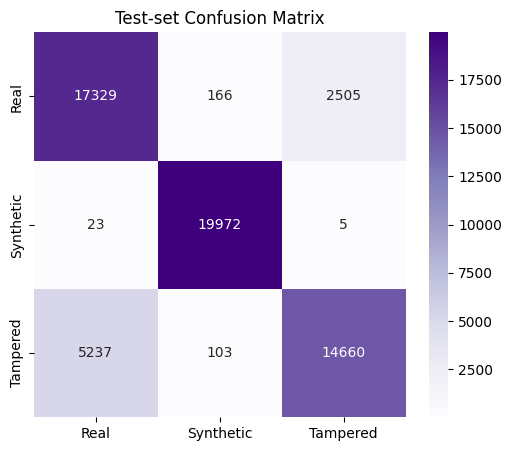

Visualizing random batch predictions...


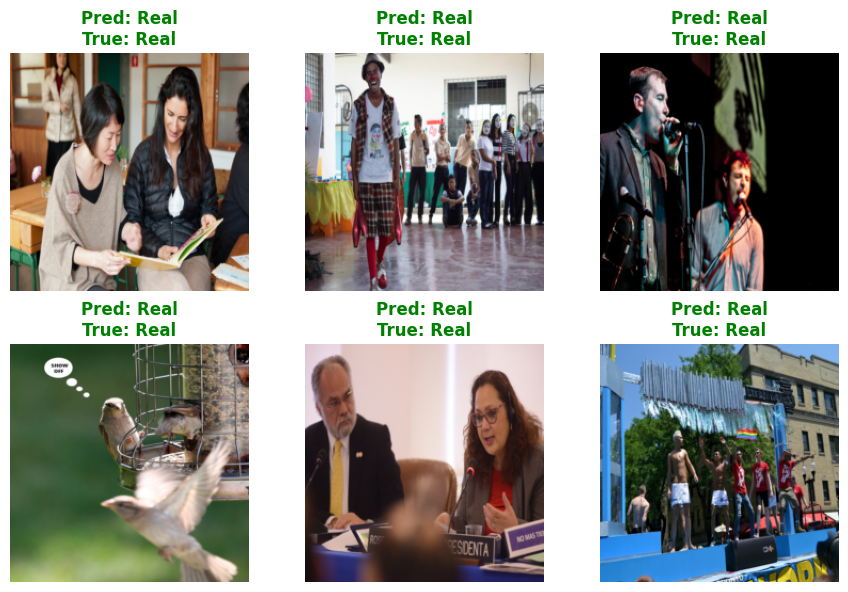

In [30]:
import time  # Needed for benchmarking


# best model weights saved from training
best_class_path = CLASS_RUN_DIR / 'best_model.pth'
if not best_class_path.exists():
    raise FileNotFoundError(f'Classifier weights not found at {best_class_path}')
ema_c.load_state_dict(torch.load(best_class_path, map_location=CLASS_DEVICE))
ema_c.eval()

# --- AUTOMATIC INFERENCE & BENCHMARKING ---
print("Starting Classification Inference on Test Set...")
test_preds, test_labels, test_paths = [], [], []

# Synchronize GPU (if used) for accurate timing
if CLASS_DEVICE.type == 'cuda':
    torch.cuda.synchronize()
    
start_time = time.time() # <--- Start Timer

with torch.no_grad():
    # Wrap the loader with tqdm to show a progress bar
    for batch in tqdm(test_loader_c, desc="Evaluating & Benchmarking"):
        # Move inputs to device (this counts towards practical throughput)
        images = batch['image'].to(CLASS_DEVICE)
        
        logits = ema_c(images)
        preds = logits.argmax(dim=1)
        
        test_preds.extend(preds.cpu().tolist())
        test_labels.extend(batch['label'].cpu().tolist())
        test_paths.extend(batch['path'])

# Synchronize GPU again
if CLASS_DEVICE.type == 'cuda':
    torch.cuda.synchronize()
    
end_time = time.time()   # <--- End Timer

# --- CALCULATE SPEED METRICS ---
total_time = end_time - start_time
num_samples = len(test_dataset_c)
fps = num_samples / total_time
avg_latency_ms = (total_time / num_samples) * 1000

print(f"\n--- INFERENCE PERFORMANCE ---")
print(f"Total Samples processed: {num_samples}")
print(f"Total Time:              {total_time:.4f} seconds")
print(f"Throughput:              {fps:.2f} images/sec")
print(f"Average Latency:         {avg_latency_ms:.2f} ms/image")
print("-" * 30)

# Calculate the classification report and confusion matrix
report_test = classification_report(
    test_labels,
    test_preds,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
cm_test = confusion_matrix(test_labels, test_preds)

# Save the final metrics to a JSON file (now including speed)
test_eval_path = CLASS_RUN_DIR / 'test_evaluation.json'
with test_eval_path.open('w') as fp:
    json.dump({
        'num_samples': num_samples,
        'inference_speed_fps': fps,
        'avg_latency_ms': avg_latency_ms,
        'classification_report': report_test,
        'confusion_matrix': cm_test.tolist(),
    }, fp, indent=2)

print(f"Saved classification metrics to {test_eval_path}")
print(f"Test-set Macro F1: {report_test['macro avg']['f1-score']:.4f}")

# --- QUALITATIVE ASSESSMENT (VISUALIZATION) ---
print("\n--- QUALITATIVE ASSESSMENT ---")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Test-set Confusion Matrix')
plt.show()

# Visual Sample Batch
print("Visualizing random batch predictions...")
sample_batch = next(iter(test_loader_c))
images = sample_batch['image'][:6].to(CLASS_DEVICE)
labels = sample_batch['label'][:6]
with torch.no_grad():
    preds = ema_c(images).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, img, pred, label in zip(axes.flatten(), images.cpu(), preds, labels):
    ax.imshow(denormalize(img))
    # Color code title: Green if correct, Red if wrong
    color = 'green' if pred == label else 'red'
    ax.set_title(f"Pred: {CLASS_NAMES[int(pred)]}\nTrue: {CLASS_NAMES[int(label)]}", color=color, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

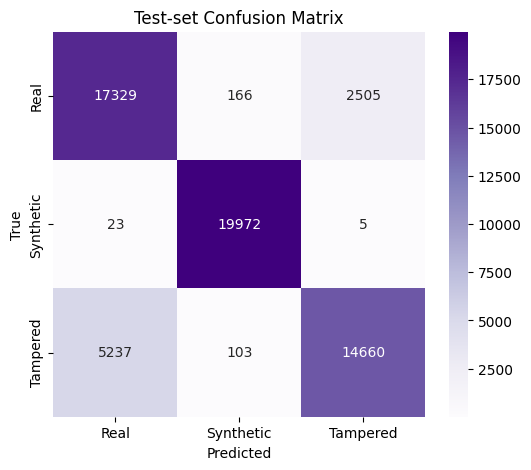

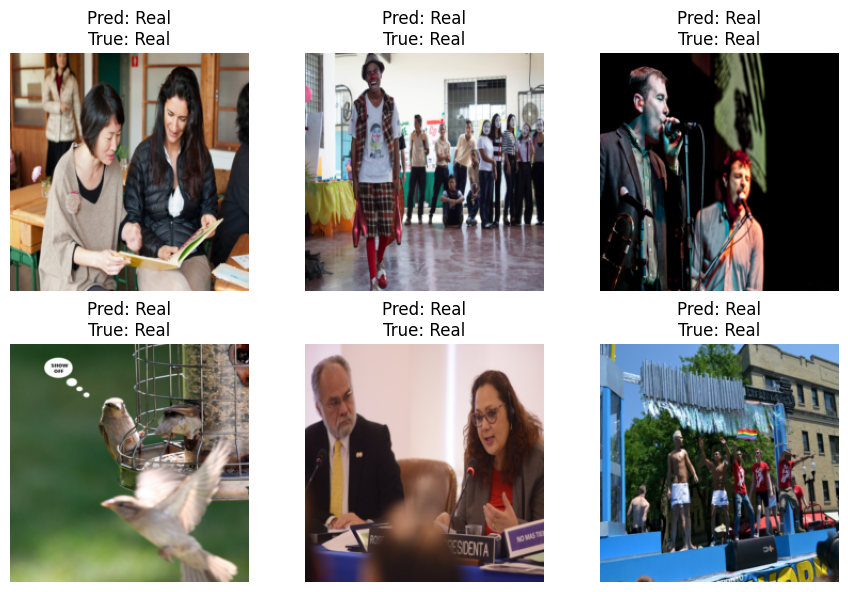

Sample misclassifications:
 - Pred=Tampered  | True=Real      | test-set/real/0010729972da6b48.jpg
 - Pred=Tampered  | True=Real      | test-set/real/00396a8814bde4d5.jpg
 - Pred=Tampered  | True=Real      | test-set/real/004e5b1e27ae550e.jpg
 - Pred=Tampered  | True=Real      | test-set/real/0051803283b6bef6.jpg
 - Pred=Tampered  | True=Real      | test-set/real/0052acec97fd255b.jpg


In [31]:
# Plot the confusion matrix as a heatmap.
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Test-set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Display a sample of predictions on test images.
sample_batch = next(iter(test_loader_c))
images = sample_batch['image'][:6].to(CLASS_DEVICE)
labels = sample_batch['label'][:6]
with torch.no_grad():
    preds = ema_c(images).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, img, pred, label in zip(axes.flatten(), images.cpu(), preds, labels):
    ax.imshow(denormalize(img))
    ax.set_title(f"Pred: {CLASS_NAMES[int(pred)]}\nTrue: {CLASS_NAMES[int(label)]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# List some of the misclassified samples for error analysis.
misclassified = [
    (path, CLASS_NAMES[pred], CLASS_NAMES[label])
    for path, pred, label in zip(test_paths, test_preds, test_labels)
    if pred != label
]
if misclassified:
    print('Sample misclassifications:')
    for path, pred, label in misclassified[:5]:
        print(f' - Pred={pred:<9} | True={label:<9} | {path}')
else:
    print('All test samples were classified correctly.')


### Segmentation — local test-set

We pair each tampered frame with its available mask and evaluate the EMA model with the deterministic validation transforms, mirroring the validation-time reporting.


In [32]:
# A custom Dataset for loading image-mask pairs from local file paths.
class LocalSegmentationPairs(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_path, mask_path = self.pairs[idx]
        with Image.open(image_path) as img:
            image = img.copy()
        with Image.open(mask_path) as mask_img:
            mask = mask_img.copy()
        return {'image': image, 'mask': mask}

# Build a lookup table to quickly find masks by their base filename.
# (e.g., "image123_mask.png" -> "image123")
mask_lookup = {}
for mask_path in SEG_TEST_MASK_DIR.iterdir():
    if is_image_file(mask_path):
        stem = mask_path.stem
        if stem.endswith('_mask'):
            mask_lookup[stem[:-5]] = mask_path

# Iterate through tampered images and find their corresponding masks.
seg_pairs = []
missing_masks = []
for img_path in sorted(SEG_TEST_IMAGE_DIR.iterdir()):
    if not is_image_file(img_path):
        continue
    key = img_path.stem
    mask_path = mask_lookup.get(key)
    if mask_path is None:
        missing_masks.append(img_path.name)
        continue
    seg_pairs.append((img_path, mask_path))

if not seg_pairs:
    raise RuntimeError('No image/mask pairs were found in the test-set.')

print(f'Paired {len(seg_pairs)} tampered frames with masks for testing.')
if missing_masks:
    print(f'Skipped {len(missing_masks)} frames that lack a mask.')

# Reuse the validation transforms and the SegmentationDataset wrapper.
joint_eval, img_eval_tf, mask_eval_tf = SEG_DATA_CONTEXT['eval_transforms']
local_seg_dataset = LocalSegmentationPairs(seg_pairs)
test_dataset_s = SegmentationDataset(
    local_seg_dataset,
    joint_transform=joint_eval,
    image_transform=img_eval_tf,
    mask_transform=mask_eval_tf,
)

# Configure and create the final DataLoader.
seg_loader_kwargs = {
    'batch_size': SEG_CFG['loader']['batch_size'],
    'num_workers': SEG_CFG['loader']['num_workers'],
    'pin_memory': SEG_CFG['loader']['pin_memory'],
}
if seg_loader_kwargs['num_workers'] > 0:
    seg_loader_kwargs['prefetch_factor'] = SEG_CFG['loader']['prefetch_factor']
    seg_loader_kwargs['persistent_workers'] = SEG_CFG['loader']['persistent_workers']

test_loader_s = DataLoader(test_dataset_s, shuffle=False, **seg_loader_kwargs)
print('Segmentation test batches:', len(test_loader_s))

Paired 20000 tampered frames with masks for testing.
Segmentation test batches: 625


In [33]:
import time

# Load the best model weights saved during training
if not SEG_BEST_PATH.exists():
    raise FileNotFoundError(f'Segmentation weights not found at {SEG_BEST_PATH}')
SEG_EMA.load_state_dict(torch.load(SEG_BEST_PATH, map_location=SEG_DEVICE))
SEG_EMA.eval()

# Initialize containers for metrics and examples
thresholds = SEG_CFG['evaluation']['thresholds']
threshold_stats = {str(th): {'tp': 0.0, 'fp': 0.0, 'fn': 0.0} for th in thresholds}
dice_scores, iou_scores = [], []
worst_examples, best_examples = [], []
gallery_limit = max(SEG_CFG['evaluation']['gallery_examples'], 4)

def _update_gallery(bank, sample, *, reverse=False):
    bank.append(sample)
    bank.sort(key=lambda row: row[0], reverse=reverse)
    if len(bank) > gallery_limit:
        bank.pop(-1)

# --- AUTOMATIC INFERENCE & BENCHMARKING ---
print("Starting Segmentation Inference on Test Set...")
if SEG_DEVICE.type == 'cuda':
    torch.cuda.synchronize()

start_time = time.time() # <--- Start Timer

with torch.no_grad():
    for batch in tqdm(test_loader_s, desc="Evaluating & Benchmarking"):
        images = batch['image'].to(SEG_DEVICE)
        masks = batch['mask'].to(SEG_DEVICE)
        
        logits = SEG_EMA(images)
        probs = torch.sigmoid(logits)

        # Calculate soft Dice and IoU scores
        intersection = (probs * masks).sum(dim=(1, 2, 3))
        preds_sum = probs.sum(dim=(1, 2, 3))
        masks_sum = masks.sum(dim=(1, 2, 3))
        dice_batch = (2 * intersection + 1e-7) / (preds_sum + masks_sum + 1e-7)
        union = preds_sum + masks_sum - intersection
        iou_batch = (intersection + 1e-7) / (union + 1e-7)
        dice_scores.extend(dice_batch.cpu().tolist())
        iou_scores.extend(iou_batch.cpu().tolist())

        # Collect stats for threshold sweep
        for th in thresholds:
            preds = (probs > th).float()
            stats = threshold_stats[str(th)]
            stats['tp'] += (preds * masks).sum().item()
            stats['fp'] += (preds * (1 - masks)).sum().item()
            stats['fn'] += ((1 - preds) * masks).sum().item()

        # Save examples for qualitative gallery
        preds_binary = (probs > 0.5).float()
        for idx in range(images.size(0)):
            sample_dice = float(seg_binary_dice(logits[idx:idx+1], masks[idx:idx+1]))
            sample = (
                sample_dice,
                images[idx].detach().cpu(),
                masks[idx].detach().cpu(),
                preds_binary[idx].detach().cpu(),
            )
            # Keep track of best and worst predictions
            _update_gallery(worst_examples, sample, reverse=False) # Sort ascending (worst first)
            _update_gallery(best_examples, sample, reverse=True)  # Sort descending (best first)

if SEG_DEVICE.type == 'cuda':
    torch.cuda.synchronize()
end_time = time.time() # <--- End Timer

# --- CALCULATE SPEED METRICS ---
total_time = end_time - start_time
num_samples = len(test_dataset_s)
fps = num_samples / total_time
avg_latency_ms = (total_time / num_samples) * 1000

print(f"\n--- INFERENCE PERFORMANCE ---")
print(f"Total Samples:   {num_samples}")
print(f"Total Time:      {total_time:.4f}s")
print(f"Throughput:      {fps:.2f} masks/sec")
print(f"Average Latency: {avg_latency_ms:.2f} ms/image")
print("-" * 30)

Starting Segmentation Inference on Test Set...


Evaluating & Benchmarking: 100%|██████████| 625/625 [01:58<00:00,  5.27it/s]



--- INFERENCE PERFORMANCE ---
Total Samples:   20000
Total Time:      118.9014s
Throughput:      168.21 masks/sec
Average Latency: 5.95 ms/image
------------------------------


Saved segmentation test metrics to project_outputs_segmentation/20251128T122952Z/test_evaluation.json
Test-set Mean Dice: 0.6332 | Mean IoU: 0.5403


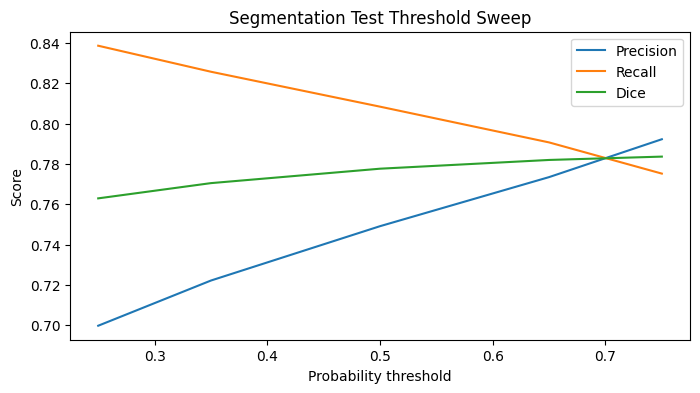

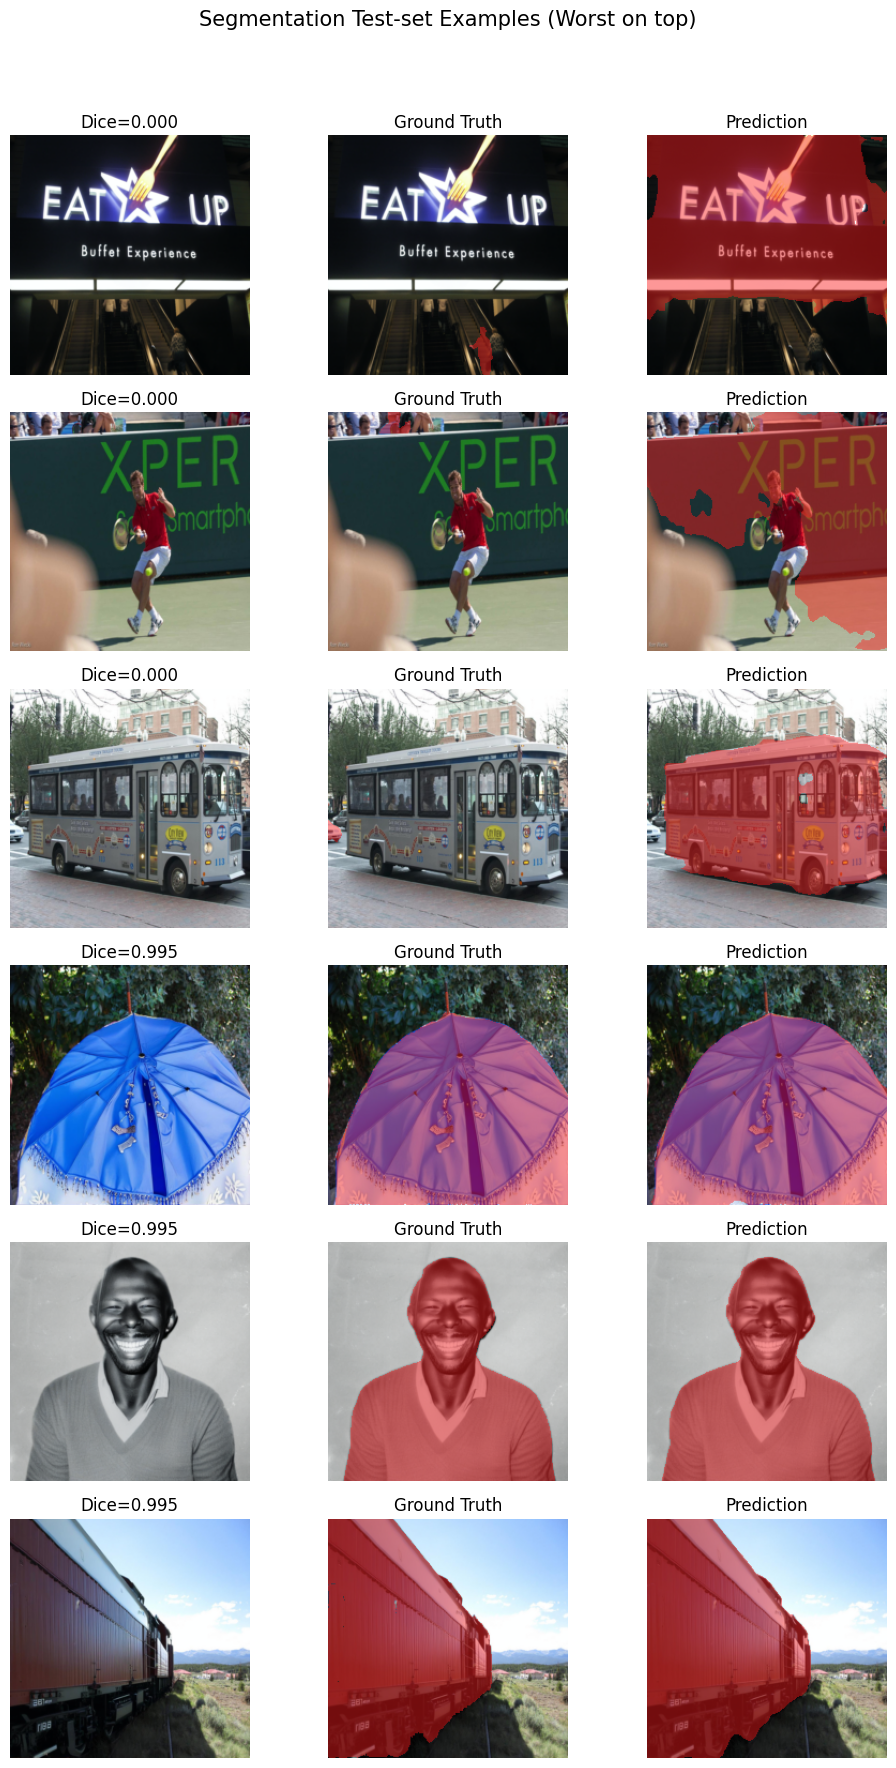

In [34]:
# Calculate final mean scores from the collected batches.
mean_dice = float(np.mean(dice_scores)) if dice_scores else float('nan')
mean_iou = float(np.mean(iou_scores)) if iou_scores else float('nan')

# Compute precision, recall, etc., for each threshold.
threshold_summary = {}
for th, stats in threshold_stats.items():
    tp, fp, fn = stats['tp'], stats['fp'], stats['fn']
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    dice = (2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7)
    iou = (tp + 1e-7) / (tp + fp + fn + 1e-7)
    threshold_summary[th] = {'precision': precision, 'recall': recall, 'dice': dice, 'iou': iou}

# Save the complete evaluation report.
seg_test_eval_path = SEG_RUN_DIR / 'test_evaluation.json'
with seg_test_eval_path.open('w') as fp:
    json.dump({
        'num_samples': len(test_dataset_s),
        'mean_dice': mean_dice,
        'mean_iou': mean_iou,
        'threshold_metrics': threshold_summary,
    }, fp, indent=2)
print(f"Saved segmentation test metrics to {seg_test_eval_path}")
print(f"Test-set Mean Dice: {mean_dice:.4f} | Mean IoU: {mean_iou:.4f}")

# Plot the threshold sweep.
plt.figure(figsize=(8, 4))
plt.plot([float(k) for k in threshold_summary.keys()], [v['precision'] for v in threshold_summary.values()], label='Precision')
plt.plot([float(k) for k in threshold_summary.keys()], [v['recall'] for v in threshold_summary.values()], label='Recall')
plt.plot([float(k) for k in threshold_summary.keys()], [v['dice'] for v in threshold_summary.values()], label='Dice')
plt.title('Segmentation Test Threshold Sweep')
plt.xlabel('Probability threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

# Display the qualitative gallery.
gallery_total = SEG_CFG['evaluation']['gallery_examples']
if gallery_total > 0 and (worst_examples or best_examples):
    half = max(1, gallery_total // 2)
    display_best = best_examples[: gallery_total - half]
    display_worst = worst_examples[:half]
    display_examples = display_worst + display_best
    fig, axes = plt.subplots(len(display_examples), 3, figsize=(10, 3 * len(display_examples)))
    if len(display_examples) == 1:
        axes = np.atleast_2d(axes)
    fig.suptitle('Segmentation Test-set Examples (Worst on top)', fontsize=15)
    for ax_row, (score, image_t, mask_t, pred_t) in zip(axes, display_examples):
        img_np = denormalize(image_t)
        mask_np = mask_t.squeeze(0).numpy()
        pred_np = pred_t.squeeze(0).numpy()

        ax_row[0].imshow(img_np)
        ax_row[0].set_title(f'Dice={score:.3f}')
        ax_row[0].axis('off')

        ax_row[1].imshow(mask_overlay(img_np, mask_np))
        ax_row[1].set_title('Ground Truth')
        ax_row[1].axis('off')

        ax_row[2].imshow(mask_overlay(img_np, pred_np))
        ax_row[2].set_title('Prediction')
        ax_row[2].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()